## Exploratory data analysis (EDA) - Manual

### By:
Gabriel Múnera González

### Date:
2026-08-20

### Description:

Exploratory data analysis (EDA) and description of the data set.

Data manipulation and visualization


## 📚 Import  libraries

In [ ]:
# base libraries for data science
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ----------------------------------------------
# To put in config script
# ----------------------------------------------
# Orden correcto de las variables ordinales
orders = {
    "clarity": ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"],
    "color": ["D", "E", "F", "G", "H", "I", "J"],
    "cut": ["Fair", "Good", "Very Good", "Premium", "Ideal"],
}


# ----------------------------------------------
# Categorical Data Analysis
# ----------------------------------------------
# ============================================================
# 3. Versión combinada: heatmap + scatter jitter en una figura
# ============================================================
def combined_view(df, var1, var1_order, var2, var2_order):
    """Combined view: heatmap + scatter jitter in one figure.
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the data.
    var1 : str
        Name of the first categorical variable (rows).
    var1_order : list
        List of categories for var1 in the desired order.
    var2 : str
        Name of the second categorical variable (columns).
    var2_order : list
        List of categories for var2 in the desired order.

    Returns
    -------
    None
        Displays the combined view.
    """
    _, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap: var1 = rows (y), var2 = columns (x)
    ct = pd.crosstab(df[var1], df[var2]).reindex(index=var1_order, columns=var2_order)
    sns.heatmap(ct, annot=True, fmt="d", cmap="viridis", ax=axes[0])
    axes[0].set_title(f"Crosstab: {var1} vs {var2}")
    axes[0].set_xlabel(var2)
    axes[0].set_ylabel(var1)
    axes[0].invert_yaxis()  # match scatter: var1_order[0] at bottom

    # Jitter scatter: natural Cartesian order, left-to-right and bottom-to-top
    map1 = {cat: i for i, cat in enumerate(var1_order)}
    map2 = {cat: i for i, cat in enumerate(var2_order)}
    x = df[var2].map(map2).astype(float) + np.random.uniform(-0.15, 0.15, size=len(df))
    y = df[var1].map(map1).astype(float) + np.random.uniform(-0.15, 0.15, size=len(df))
    axes[1].scatter(x, y, alpha=0.15, s=15, color="steelblue")
    axes[1].set_xticks(range(len(var2_order)))
    axes[1].set_xticklabels(var2_order)
    axes[1].set_yticks(range(len(var1_order)))
    axes[1].set_yticklabels(var1_order)
    axes[1].set_xlabel(var2)
    axes[1].set_ylabel(var1)
    axes[1].set_title(f"Jitter scatter: {var1} vs {var2}")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [2]:
# configuration to show only 2 decimal places
pd.set_option("display.float_format", "{:.2f}".format)

In [3]:
# print library version for reproducibility

print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.11 (main, Jul  1 2025, 05:29:09) [GCC 12.2.0]
Pandas version:  2.3.3


## 💾 Load data

The dataset has correct data types, fixed in:

`notebooks/2-exploration/01-jrz-data_explore_description-2024_03_01.ipynb`

In [4]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

diamantes_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/diamantes_type_fixed.parquet", engine="pyarrow"
)

## 📊 Data description

### General data information

In [5]:
diamantes_df.describe()

,carat,depth,table,price,x,y,z
count,19231.00,19231.00,19231.00,19231.00,19231.00,19231.00,19231.00
mean,1.32,61.78,57.92,8101.18,6.98,6.97,4.31
std,0.37,1.59,2.20,3917.48,0.60,0.71,0.38
min,1.00,43.00,43.00,1262.00,5.72,4.11,1.07
25%,1.03,61.00,56.00,5006.00,6.50,6.50,4.02
50%,1.20,61.90,58.00,6794.00,6.79,6.78,4.19
75%,1.51,62.60,59.00,10417.50,7.36,7.35,4.55
max,5.01,78.20,95.00,18823.00,10.74,58.90,8.06


In [6]:
diamantes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19231 entries, 0 to 19230
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    19231 non-null  float32 
 1   cut      19231 non-null  category
 2   color    19231 non-null  category
 3   clarity  19231 non-null  category
 4   depth    19231 non-null  float32 
 5   table    19231 non-null  float32 
 6   price    19231 non-null  int64   
 7   x        19231 non-null  float32 
 8   y        19231 non-null  float32 
 9   z        19231 non-null  float32 
dtypes: category(3), float32(6), int64(1)
memory usage: 658.3 KB


General information about the data set:

In [7]:
diamantes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19231 entries, 0 to 19230
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    19231 non-null  float32 
 1   cut      19231 non-null  category
 2   color    19231 non-null  category
 3   clarity  19231 non-null  category
 4   depth    19231 non-null  float32 
 5   table    19231 non-null  float32 
 6   price    19231 non-null  int64   
 7   x        19231 non-null  float32 
 8   y        19231 non-null  float32 
 9   z        19231 non-null  float32 
dtypes: category(3), float32(6), int64(1)
memory usage: 658.3 KB


In [8]:
# size of the dataframe
diamantes_df.shape

(19231, 10)

In [9]:
# sample of the dataframe
diamantes_df.sample(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
2501,1.04,Ideal,G,SI2,61.70,56.00,4455,6.57,6.52,4.04
3,1.00,Premium,J,SI2,62.30,58.00,2801,6.45,6.34,3.98
4613,1.17,Ideal,F,SI1,63.00,54.00,5032,6.71,6.66,4.21
2714,1.01,Good,E,SI2,58.50,61.00,4506,6.51,6.55,3.82
16622,1.53,Ideal,D,SI1,61.20,56.00,13714,7.48,7.45,4.57


Number of missing values

In [10]:
diamantes_df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Target Variable = `price`

#### General statistics of the data set

##### Numerical variables

In [11]:
diamantes_df.describe()

,carat,depth,table,price,x,y,z
count,19231.00,19231.00,19231.00,19231.00,19231.00,19231.00,19231.00
mean,1.32,61.78,57.92,8101.18,6.98,6.97,4.31
std,0.37,1.59,2.20,3917.48,0.60,0.71,0.38
min,1.00,43.00,43.00,1262.00,5.72,4.11,1.07
25%,1.03,61.00,56.00,5006.00,6.50,6.50,4.02
50%,1.20,61.90,58.00,6794.00,6.79,6.78,4.19
75%,1.51,62.60,59.00,10417.50,7.36,7.35,4.55
max,5.01,78.20,95.00,18823.00,10.74,58.90,8.06


##### Categorical variables

In [12]:
# categorical columns description
diamantes_df.describe(include="category")

,cut,color,clarity
count,19231,19231,19231
unique,5,7,8
top,Premium,G,SI2
freq,6241,4057,5421


#### Target Variable
`price` is the target variable, which is a numerical variable. The distribution of the target variable is shown below.

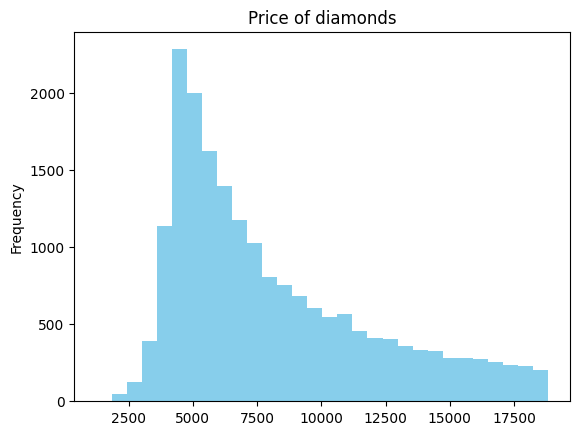

In [13]:
diamantes_df["price"].plot(
    kind="hist", color=["skyblue", "orange"], title="Price of diamonds", bins=30
);

#### Numerical Variables

In [14]:
# list of the numerical columns
numerical_columns = list(diamantes_df.select_dtypes(include=["number"]).columns)
numerical_columns

['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

##### carat

In [15]:
column = "carat"
diamantes_df[column].describe()

count   19231.00
mean        1.32
std         0.37
min         1.00
25%         1.03
50%         1.20
75%         1.51
max         5.01
Name: carat, dtype: float64

In [16]:
# number of unique values
diamantes_df[column].nunique()

193

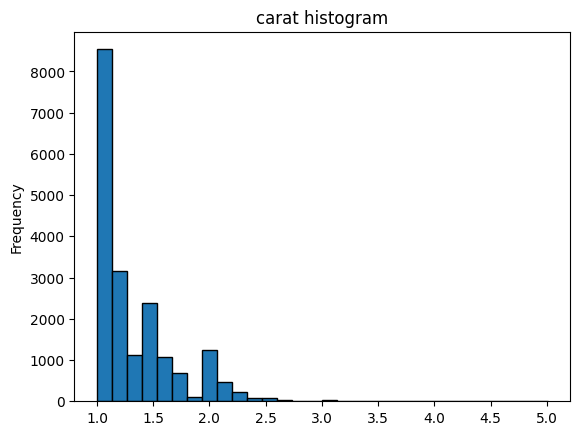

In [ ]:
diamantes_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

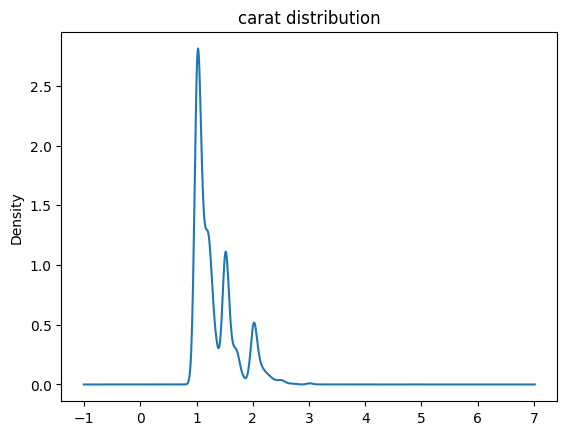

In [18]:
diamantes_df[column].plot(kind="density", title=f"{column} distribution");

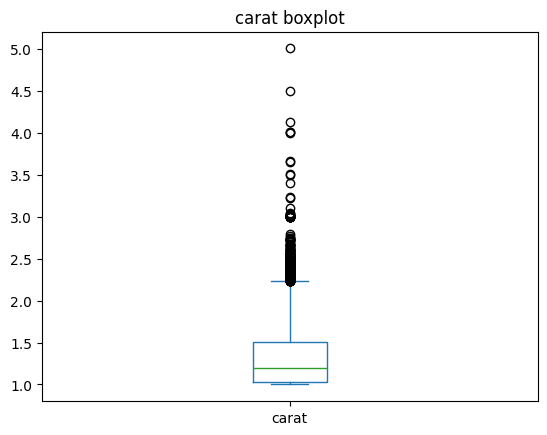

In [19]:
diamantes_df[column].plot(kind="box", title=f"{column} boxplot");

##### depth

In [20]:
column = "depth"
diamantes_df[column].describe()

count   19231.00
mean       61.78
std         1.59
min        43.00
25%        61.00
50%        61.90
75%        62.60
max        78.20
Name: depth, dtype: float64

In [21]:
# number of unique values
diamantes_df[column].nunique()

159

In [22]:
# unique values (because are only a few)
diamantes_df[column].unique()

array([61.8, 65.8, 62.2, 62.3, 66.4, 64.6, 61.6, 58.9, 61.5, 63.1, 59.3,
       65.4, 64.2, 59.1, 63.6, 53. , 67.8, 67.9, 66.1, 60.9, 67.6, 61.9,
       61.7, 65.5, 67.7, 66.3, 69.5, 60.3, 62. , 65.3, 62.7, 65.1, 60.6,
       58.3, 65.2, 66. , 67. , 60.5, 57.6, 65.7, 67.1, 65.6, 61.4, 64.8,
       59.9, 69.3, 62.5, 63.2, 61. , 64.9, 66.2, 55.4, 61.1, 61.2, 60.8,
       63.3, 66.8, 63.8, 63.5, 60.2, 68.1, 62.4, 61.3, 66.6, 59.4, 62.8,
       64.5, 63.7, 57.3, 64.1, 68.2, 65. , 63.4, 58.8, 68.3, 57.2, 62.6,
       60.1, 68.5, 57.4, 56.2, 64.4, 56.3, 63.9, 62.1, 60. , 60.4, 62.9,
       66.5, 60.7, 58.2, 58.4, 59.6, 63. , 64. , 57.1, 64.3, 59.8, 68.7,
       59.2, 58.6, 58.5, 59. , 59.5, 57.8, 64.7, 58.1, 67.3, 66.7, 58. ,
       59.7, 58.7, 43. , 67.4, 57.7, 67.5, 57.9, 69. , 55.2, 68.9, 57.5,
       56.7, 69.6, 56.9, 57. , 56.4, 56.8, 44. , 66.9, 65.9, 67.2, 68.8,
       70.1, 71.3, 70.6, 69.8, 56.5, 71.8, 69.7, 68.4, 55.9, 53.8, 53.2,
       70. , 69.4, 55.8, 56.6, 68. , 70.2, 50.8, 55

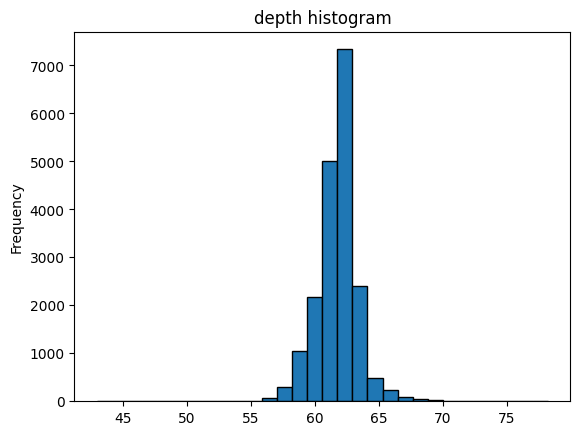

In [ ]:
# histogram of a column with 7 unique values between 0 and 8
diamantes_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

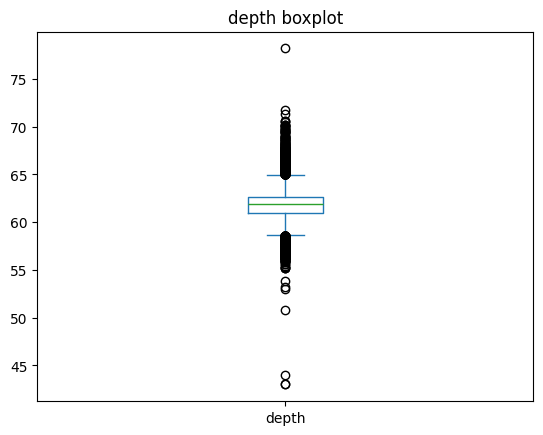

In [24]:
diamantes_df[column].plot(kind="box", title=f"{column} boxplot");

##### table

In [25]:
column = "table"
diamantes_df[column].describe()

count   19231.00
mean       57.92
std         2.20
min        43.00
25%        56.00
50%        58.00
75%        59.00
max        95.00
Name: table, dtype: float64

In [26]:
# number of unique values
diamantes_df[column].nunique()

95

In [27]:
# unique values (because are only a few)
diamantes_df[column].unique()

array([60. , 59. , 58. , 56. , 61. , 57. , 63. , 55. , 62. , 54. , 64. ,
       66. , 53. , 67. , 65. , 51. , 52. , 56.9, 58.1, 68. , 60.6, 58.6,
       49. , 55.8, 55.1, 55.3, 50. , 57.7, 56.8, 57.9, 56.2, 60.3, 55.6,
       56.5, 59.5, 60.1, 57.4, 62.4, 56.3, 60.4, 54.4, 60.2, 60.8, 57.1,
       58.5, 57.6, 55.7, 54.6, 57.5, 43. , 56.1, 59.9, 53.9, 63.5, 57.3,
       61.4, 58.3, 57.2, 55.9, 56.4, 55.4, 54.2, 60.7, 58.2, 55.2, 54.9,
       56.7, 59.4, 54.5, 54.7, 56.6, 54.8, 53.6, 55.5, 58.7, 57.8, 53.8,
       54.1, 69. , 59.1, 54.3, 53.2, 53.5, 59.3, 53.3, 53.7, 70. , 61.1,
       51.6, 58.8, 95. , 61.2, 59.2, 60.5, 53.4], dtype=float32)

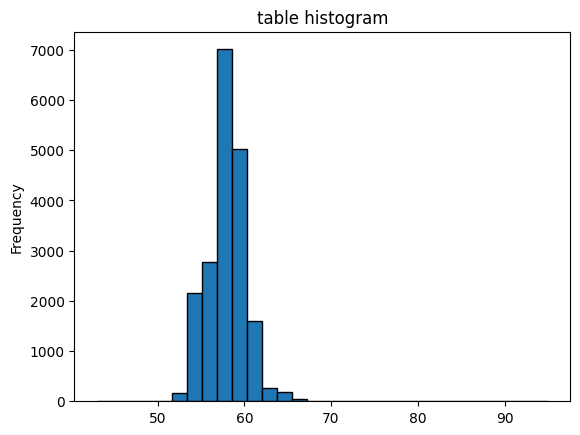

In [ ]:
diamantes_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

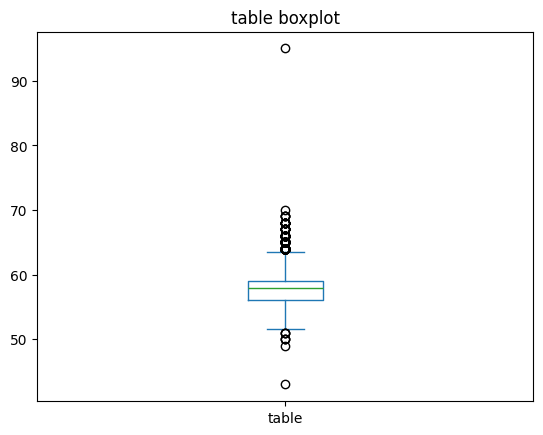

In [29]:
diamantes_df[column].plot(kind="box", title=f"{column} boxplot");

##### x

In [30]:
column = "x"
diamantes_df[column].describe()

count   19231.00
mean        6.98
std         0.60
min         5.72
25%         6.50
50%         6.79
75%         7.36
max        10.74
Name: x, dtype: float64

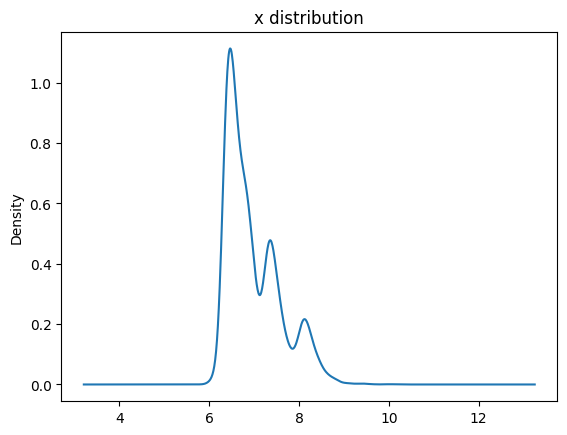

In [31]:
diamantes_df[column].plot(kind="kde", title=f"{column} distribution");

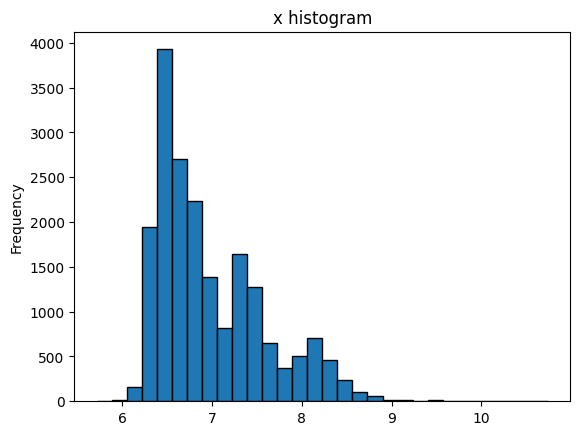

In [ ]:
diamantes_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

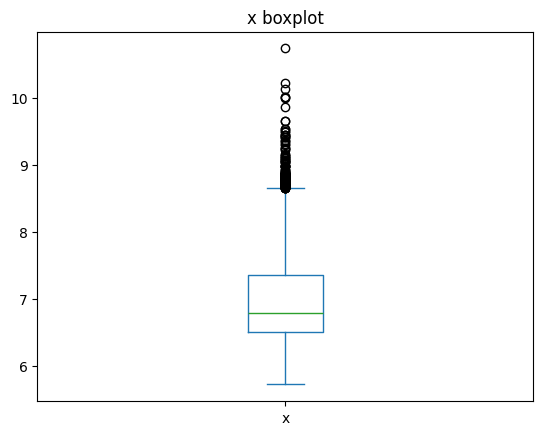

In [33]:
diamantes_df[column].plot(kind="box", title=f"{column} boxplot");

##### y

In [34]:
column = "y"
diamantes_df[column].describe()

count   19231.00
mean        6.97
std         0.71
min         4.11
25%         6.50
50%         6.78
75%         7.35
max        58.90
Name: y, dtype: float64

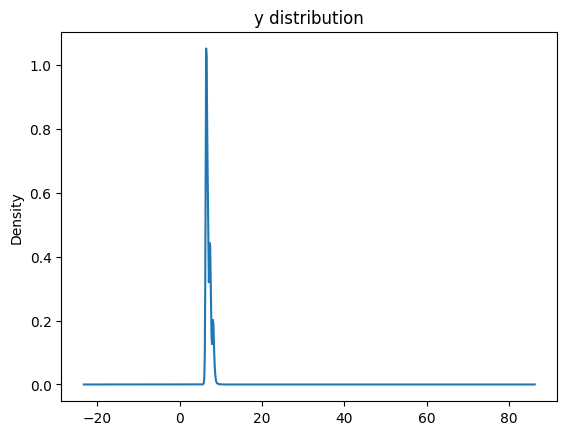

In [35]:
diamantes_df[column].plot(kind="kde", title=f"{column} distribution");

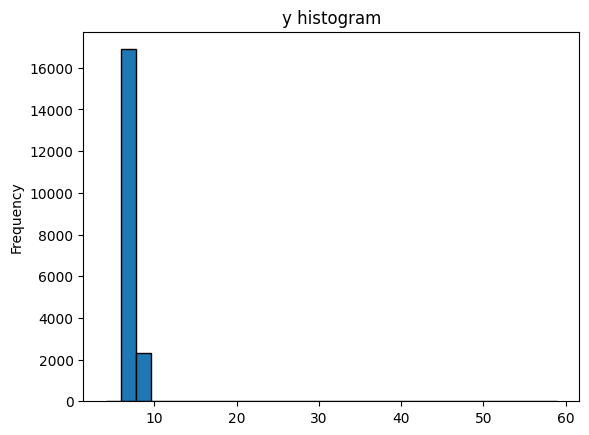

In [ ]:
diamantes_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

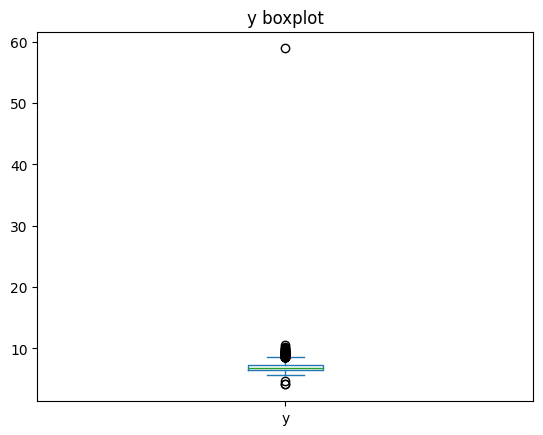

In [37]:
diamantes_df[column].plot(kind="box", title=f"{column} boxplot");

##### z

In [38]:
column = "z"
diamantes_df[column].describe()

count   19231.00
mean        4.31
std         0.38
min         1.07
25%         4.02
50%         4.19
75%         4.55
max         8.06
Name: z, dtype: float64

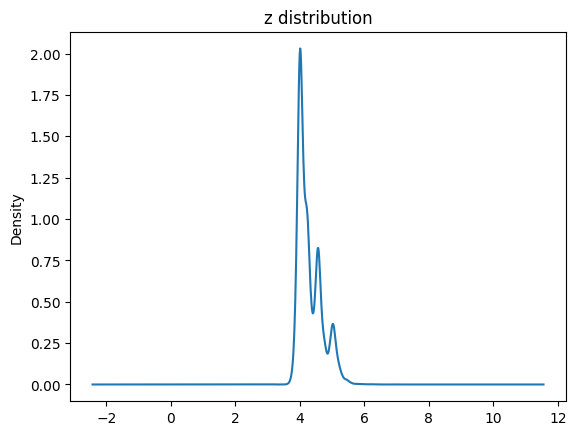

In [39]:
diamantes_df[column].plot(kind="kde", title=f"{column} distribution");

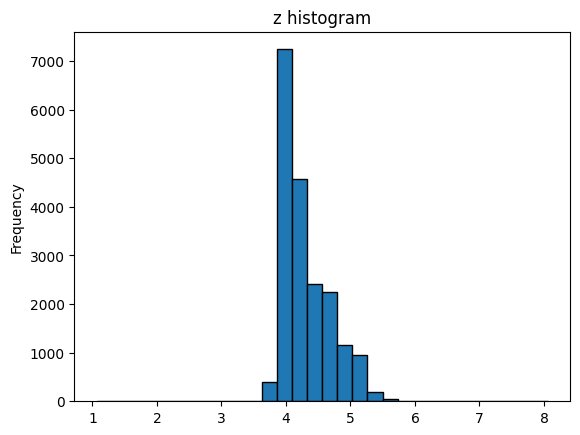

In [ ]:
diamantes_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

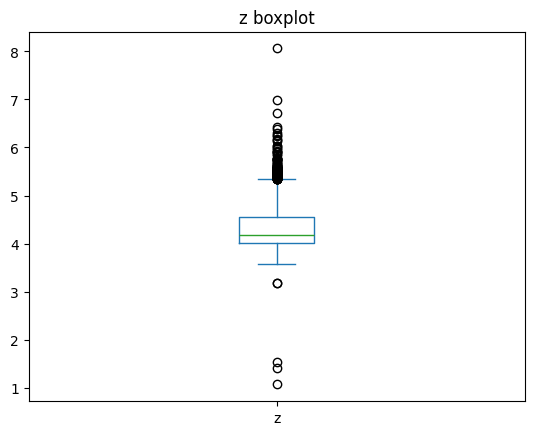

In [41]:
diamantes_df[column].plot(kind="box", title=f"{column} boxplot");

##### price

In [42]:
column = "price"
diamantes_df[column].describe()

count   19231.00
mean     8101.18
std      3917.48
min      1262.00
25%      5006.00
50%      6794.00
75%     10417.50
max     18823.00
Name: price, dtype: float64

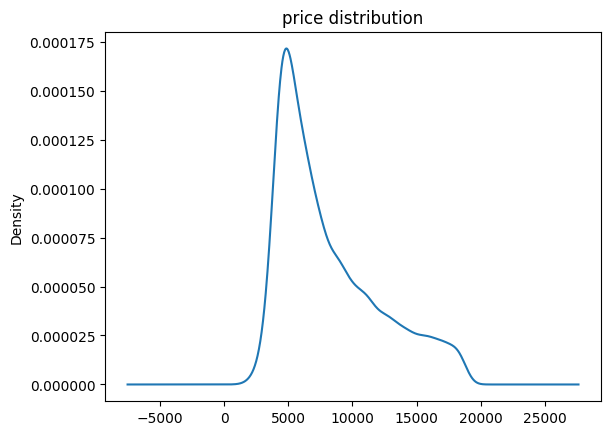

In [43]:
diamantes_df[column].plot(kind="kde", title=f"{column} distribution");

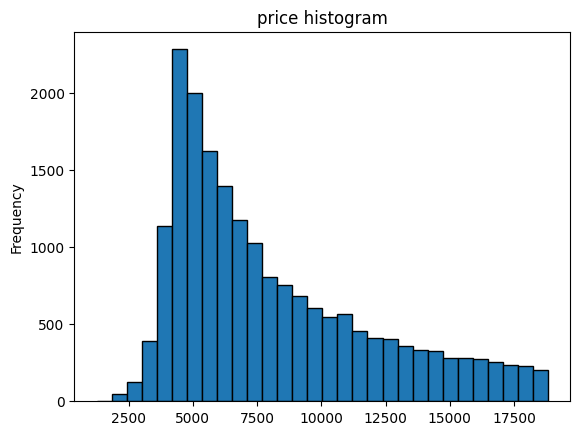

In [ ]:
diamantes_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

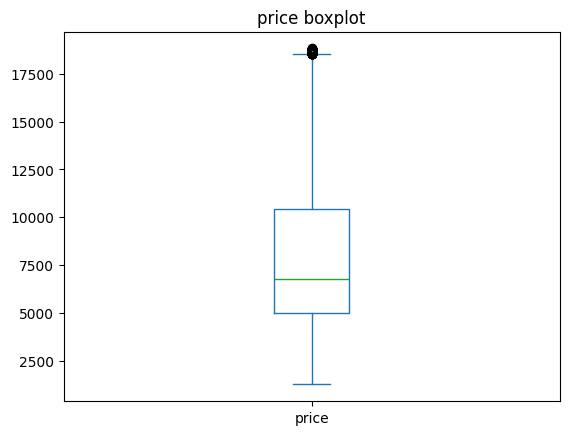

In [45]:
diamantes_df[column].plot(kind="box", title=f"{column} boxplot");

#### Categorical Variables

In [46]:
# list of the categorical columns
categorical_columns = list(diamantes_df.select_dtypes(include=["category"]).columns)
categorical_columns

['cut', 'color', 'clarity']

##### cut

In [47]:
column = "cut"
diamantes_df[column].describe()

count       19231
unique          5
top       Premium
freq         6241
Name: cut, dtype: object

In [48]:
diamantes_df[column].unique()

['Premium', 'Fair', 'Ideal', 'Good', 'Very Good']
Categories (5, object): ['Fair', 'Good', 'Ideal', 'Premium', 'Very Good']

In [49]:
diamantes_df[column].value_counts()

cut
Premium      6241
Ideal        5902
Very Good    4314
Good         1944
Fair          830
Name: count, dtype: int64

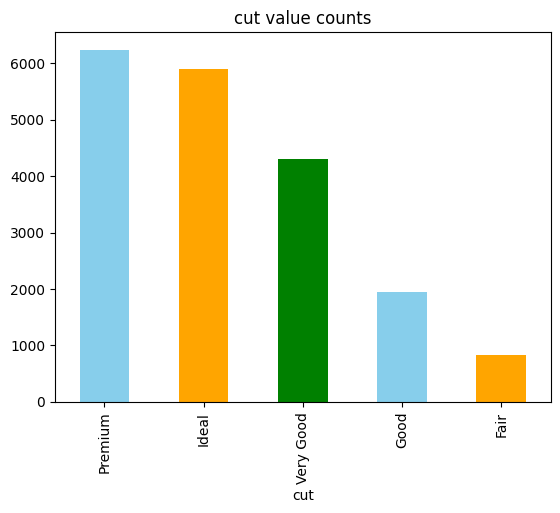

In [50]:
diamantes_df[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange", "green"], title=f"{column} value counts"
);

##### color

In [51]:
column = "color"
diamantes_df[column].describe()

count     19231
unique        7
top           G
freq       4057
Name: color, dtype: object

In [52]:
diamantes_df[column].unique()

['F', 'J', 'G', 'H', 'I', 'E', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']

In [53]:
diamantes_df[column].value_counts()

color
G    4057
H    3890
F    2988
I    2803
E    2227
J    1731
D    1535
Name: count, dtype: int64

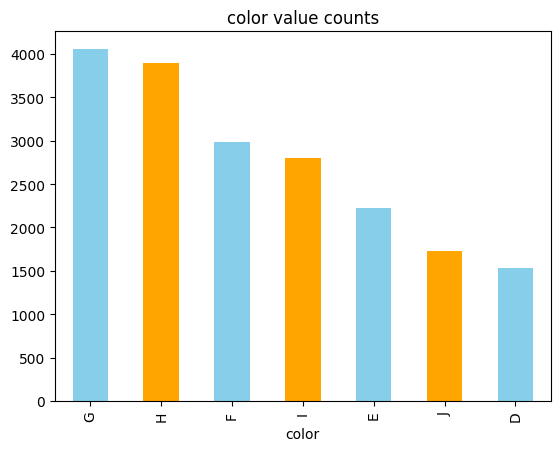

In [54]:
diamantes_df[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange"], title=f"{column} value counts"
);

##### clarity

In [55]:
column = "clarity"
diamantes_df[column].describe()

count     19231
unique        8
top         SI2
freq       5421
Name: clarity, dtype: object

In [56]:
diamantes_df[column].unique()

['I1', 'SI2', 'SI1', 'VS1', 'VVS2', 'VS2', 'VVS1', 'IF']
Categories (8, object): ['I1', 'IF', 'SI1', 'SI2', 'VS1', 'VS2', 'VVS1', 'VVS2']

In [57]:
diamantes_df[column].value_counts()

clarity
SI2     5421
SI1     5094
VS2     4020
VS1     2401
VVS2    1076
I1       531
VVS1     434
IF       254
Name: count, dtype: int64

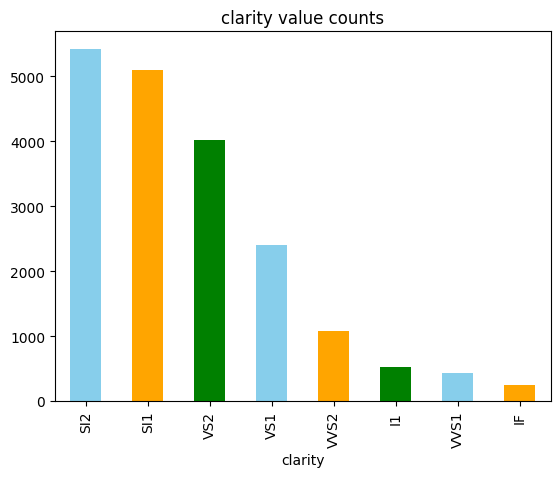

In [58]:
diamantes_df[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange", "green"], title=f"{column} value counts"
);

#### String columns

No string columns in the data set.

### 📈  Bivariate Analysis

Is important to check the relationship between the target variable and the other variables.

The target variable is `price`


#### Target vs Numerical Variables

##### price vs carat

`carat` feature seems to have some stratifying effect on the `price` variable. The relationship between `carat` and `price` is positive, meaning that as the weight increases, the price also increases (which is expected).

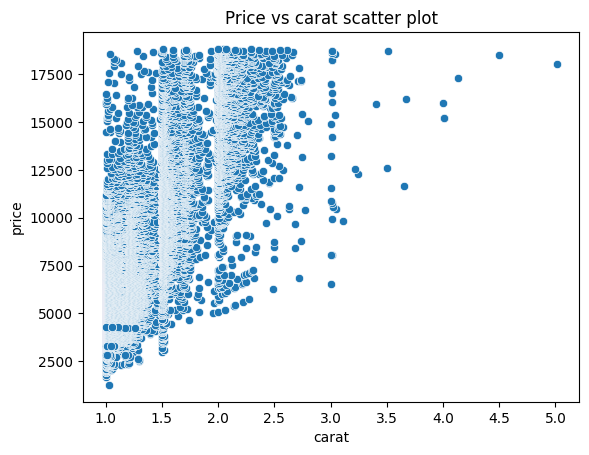

In [59]:
variable = "carat"

sns.scatterplot(data=diamantes_df, x=variable, y="price")
plt.title(f"Price vs {variable} scatter plot")
plt.show()

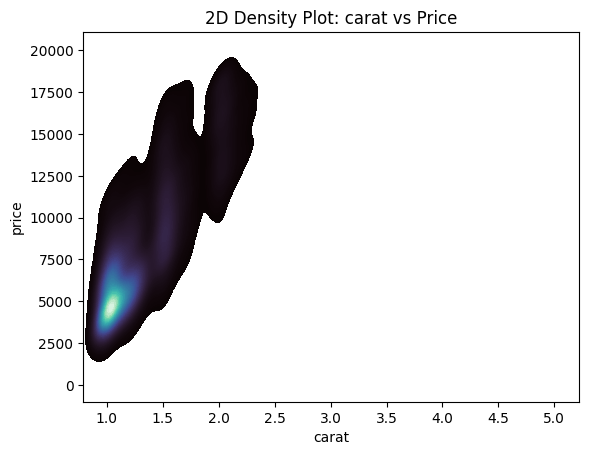

In [60]:
sns.kdeplot(
    data=diamantes_df,
    x=variable,
    y="price",
    fill=True,
    cmap="mako",
    thresh=0.05,
    levels=100,
)
plt.title(f"2D Density Plot: {variable} vs Price")
plt.show()

##### price vs depth
Seems like there's no clear relationship between `depth` and `price`. The scatter plot shows a wide spread of prices for different depth values, indicating that depth may not be a strong predictor of price. This is a weird behavior, as one would expect that depth would have some influence on price as is directly related with the size of the diamond.

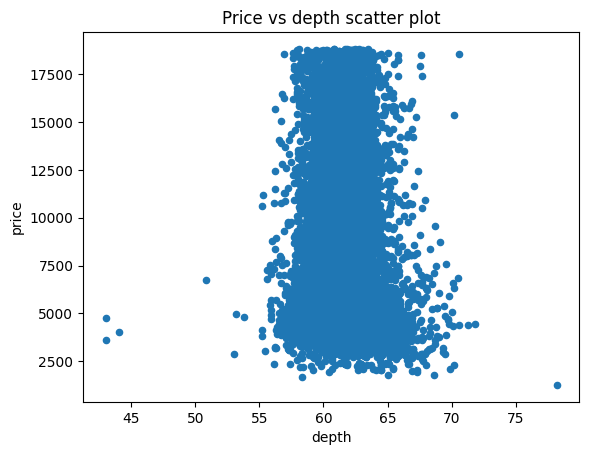

In [61]:
variable = "depth"

diamantes_df.plot(
    kind="scatter",
    x=variable,
    y="price",
    grid=False,
    title=f"Price vs {variable} scatter plot",
);

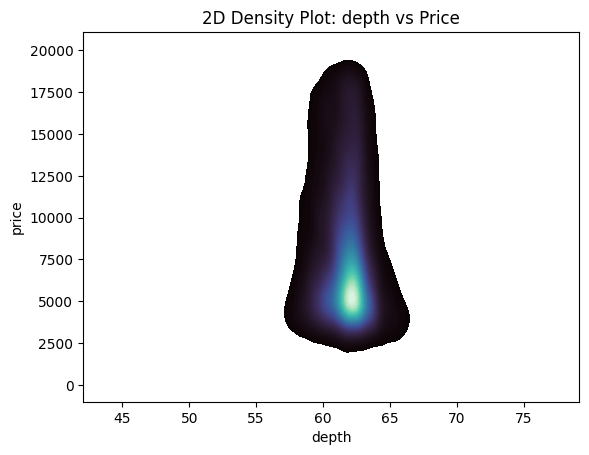

In [62]:
sns.kdeplot(
    data=diamantes_df,
    x=variable,
    y="price",
    fill=True,
    cmap="mako",
    thresh=0.05,
    levels=100,
)
plt.title(f"2D Density Plot: {variable} vs Price")
plt.show()

Let's check the analytical value of deph vs the current value

In [137]:
depth = 2 * diamantes_df["z"].div(diamantes_df["x"] + diamantes_df["y"])
print(
    f"Number of matching depth values: {int((round(depth * 100, 0) == diamantes_df['depth'].round(0)).sum())}"
)

Number of matching depth values: 18120


The previous result suggests that the `depth` variable may not be accurately representing the true depth of the diamonds, as it does not correlate with the physical dimensions (`x`, `y`, and `z`). This could indicate potential data quality issues or measurement errors in the dataset. Further investigation is needed to validate this finding and determine if any corrective actions are necessary, meanwhile we set `depth_` to the calculated depth.

In [64]:
diamantes_df["depth_"] = depth
numerical_columns.append("depth_")

##### price vs table
This variable has the same behaviour as `depth`, showing no clear relationship with `price`. The scatter plot indicates that the `table` variable may not be a strong predictor of price either. In this case, is possible that the width of top of diamond relative to widest point of diamond (table) may not have a significant impact on the price, as other factors such as carat weight, cut, color, and clarity may play a more important role in determining the value of a diamond.

Scatter plot also shows an outlier that was excluded from the visualization to get a better picture of the relation

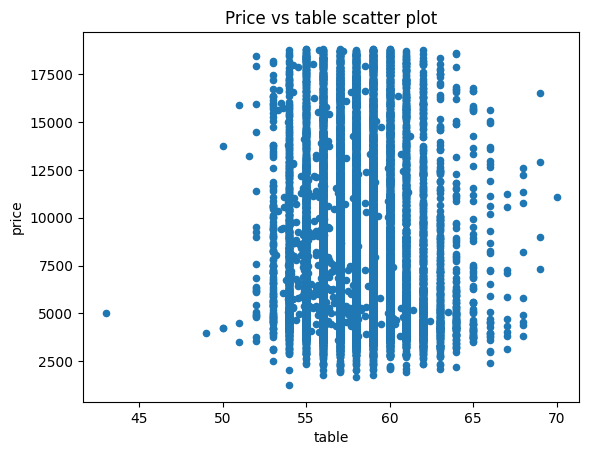

In [ ]:
variable = "table"
table_cutoff = 80
diamantes_df[diamantes_df[variable] < table_cutoff].plot(
    kind="scatter",
    x=variable,
    y="price",
    grid=False,
    title=f"Price vs {variable} scatter plot",
);

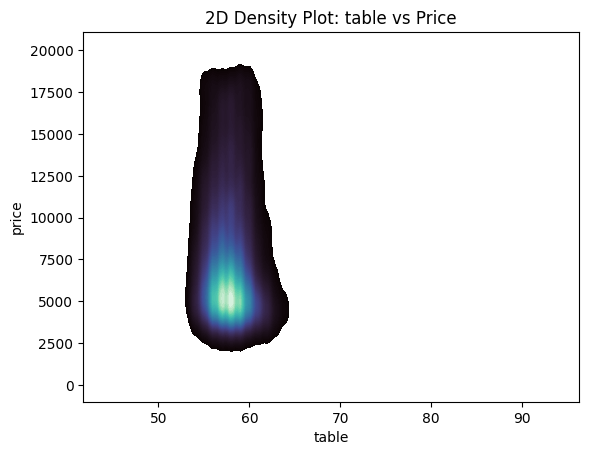

In [66]:
sns.kdeplot(
    data=diamantes_df,
    x=variable,
    y="price",
    fill=True,
    cmap="mako",
    thresh=0.05,
    levels=100,
)
plt.title(f"2D Density Plot: {variable} vs Price")
plt.show()

##### price vs x
This is one of the most correlated variables with `price`, as it represents the length of the diamond. The scatter plot shows a positive relationship, indicating that larger diamonds tend to have higher prices. This is consistent with the expectation that larger diamonds are more valuable. 

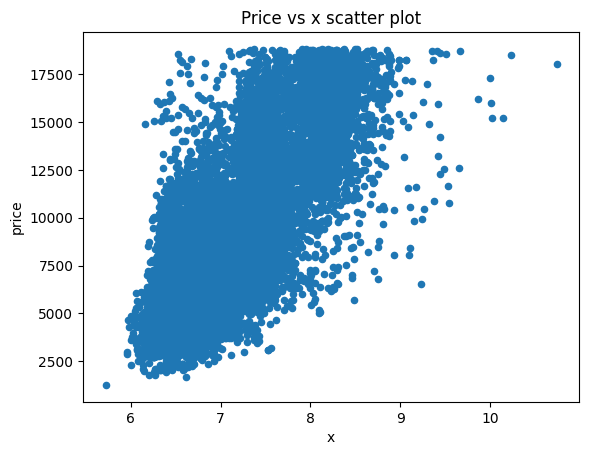

In [67]:
variable = "x"

diamantes_df.plot(
    kind="scatter",
    x=variable,
    y="price",
    grid=False,
    title=f"Price vs {variable} scatter plot",
);

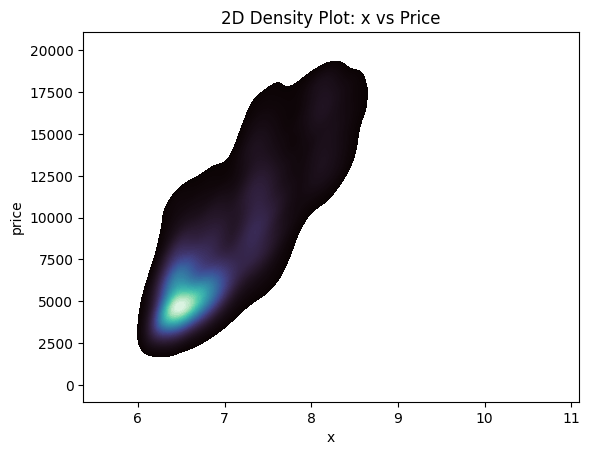

In [68]:
sns.kdeplot(
    data=diamantes_df,
    x=variable,
    y="price",
    fill=True,
    cmap="mako",
    thresh=0.05,
    levels=100,
)
plt.title(f"2D Density Plot: {variable} vs Price")
plt.show()

##### price vs y
Seems like there is a positive relationship between `y` (width) and `price`, similar to the relationship observed with `x`. Seems like a very small change in y can have a significant impact on the price, indicating that width is an important factor in determining the value of a diamond. The scatter plot shows a clear trend, with higher prices associated with larger widths.

We can see a very clear outlier in the scatter plot, which may indicate a data entry error or an unusual diamond. Further investigation is needed to determine the cause of this outlier and whether it should be removed from the analysis. We exclude this value from the plot to better visualize the relationship between `y` and `price`. Further processing must consider dropping the outlier.

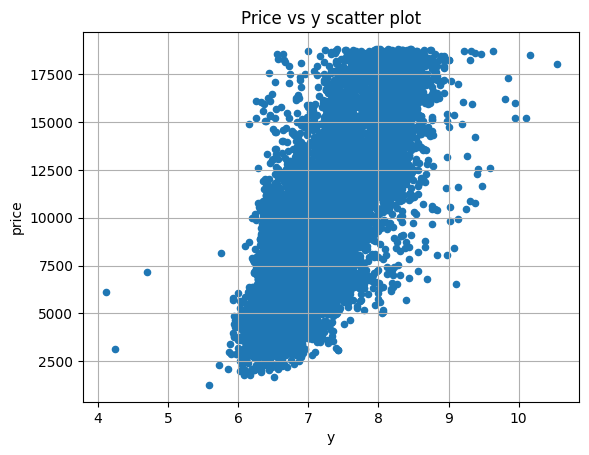

In [ ]:
variable = "y"
y_cutoff = 80

diamantes_df[diamantes_df[variable] < y_cutoff].plot(
    kind="scatter",
    x=variable,
    y="price",
    grid=True,
    title=f"Price vs {variable} scatter plot",
);

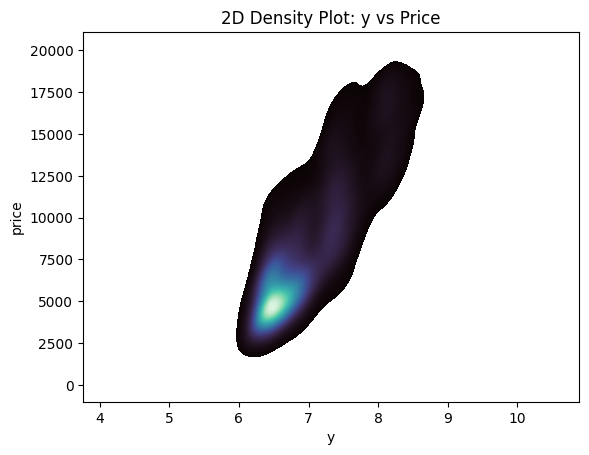

In [ ]:
sns.kdeplot(
    data=diamantes_df[diamantes_df[variable] < y_cutoff],
    x=variable,
    y="price",
    fill=True,
    cmap="mako",
    thresh=0.05,
    levels=100,
)
plt.title(f"2D Density Plot: {variable} vs Price")
plt.show()

##### price vs z
The `z` variable, which represents the depth of the diamond, shows a positive relationship with `price`, similar to the relationships observed with `x` and `y`. However, the scatter plot indicates that there may be some variability in the relationship, suggesting that other factors may also influence the price.

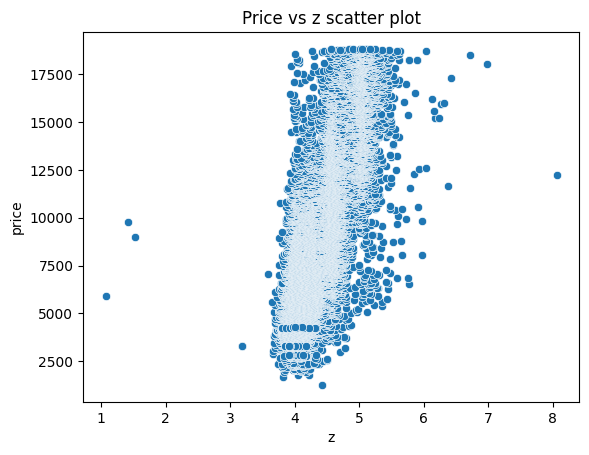

In [71]:
variable = "z"

sns.scatterplot(
    data=diamantes_df,
    x=variable,
    y="price",
    # hue='clarity'
)
plt.title(f"Price vs {variable} scatter plot")
plt.show()

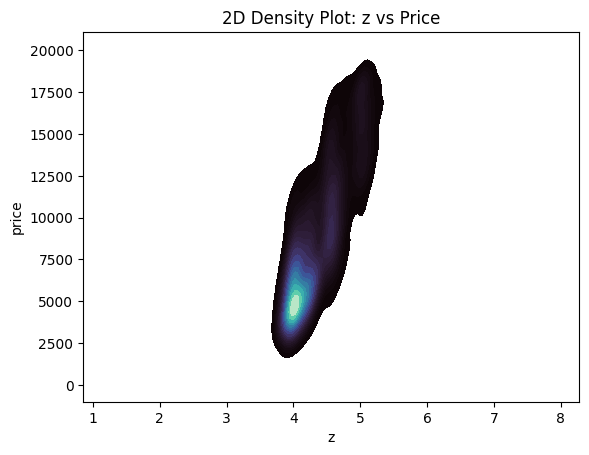

In [72]:
sns.kdeplot(
    data=diamantes_df,
    x=variable,
    y="price",
    fill=True,
    cmap="mako",
    thresh=0.05,
    levels=20,
)
plt.title(f"2D Density Plot: {variable} vs Price")
plt.show()

##### Conclusion of target vs numerical variables

Across the four size-related variables (`carat`, `x`, `y`, `z`) the relationship with `price` is consistently positive and the strongest we observe in the whole dataset (Pearson r ≈ 0.79 for `carat` and `x`, 0.77 for `z`, 0.69 for `y`), confirming that size/weight is the dominant price driver — consistent with the funnel-shaped, heteroscedastic scatter and 2D density plots (the spread of `price` widens as size increases).

`depth` and `table` behave completely differently: both scatter/KDE plots against `price` show a shapeless cloud, and their correlation with `price` is essentially zero (r ≈ -0.07 and -0.03). This isn't very surprising: unlike `carat`/`x`/`y`/`z`, `depth` and `table` are proportions of the stone's own dimensions (relative height and top-width), so they encode cut geometry rather than size — two diamonds of very different price can share the same proportions. The apparent mismatch between the reported `depth` and the value computed as `2*z/(x+y)` (0 exact matches) flagged above turns out to be a unit-scale artifact rather than a data-quality problem — this is resolved with hard numbers in the Multivariate Analysis section below.

Two clear outliers surface repeatedly in these plots and are worth carrying forward: one record with `y` ≈ 58.9 (physically impossible for a ~2 carat stone) and a few records with `z` far below the rest of the distribution. Both are pinpointed and explained in the Multivariate Analysis section.

#### Target vs Categorical Variables
We'll use a violin plot to visualize the relationship between the target variable and the categorical variables. We will also use a scatter plot `price vs x` with color segmentation to visualize the relationship between the target variable and the categorical variables. We chose `x` because the great correlations against price it shows.

##### price vs clarity
There is a clear strong influence of the clarity of the diamond on its price. The violin plot shows that diamonds with higher clarity grades tend to have higher prices, while those with lower clarity grades tend to have lower prices. This is consistent with the expectation that diamonds with fewer inclusions and blemishes are more valuable.

Scatter plot reveals the stratified effect of the `clarity` variable on the relationship between `x` and `price`. The different colors represent different clarity grades, and we can see that diamonds with higher clarity grades tend to have higher prices for a given length (`x`). This indicates that clarity is an important factor in determining the value of a diamond, in addition to its size.

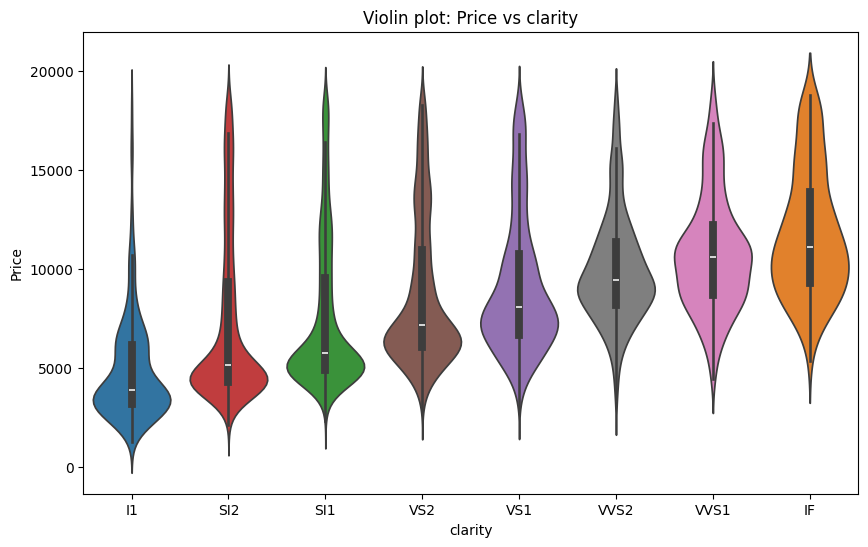

In [73]:
variable = "clarity"

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=diamantes_df,
    x=variable,
    y="price",
    order=orders[variable],  # adjust order for your variable
    hue=variable,
    inner="box",
    density_norm="width",
)
plt.title(f"Violin plot: Price vs {variable}")
plt.ylabel("Price")
plt.xlabel(variable)
plt.show()

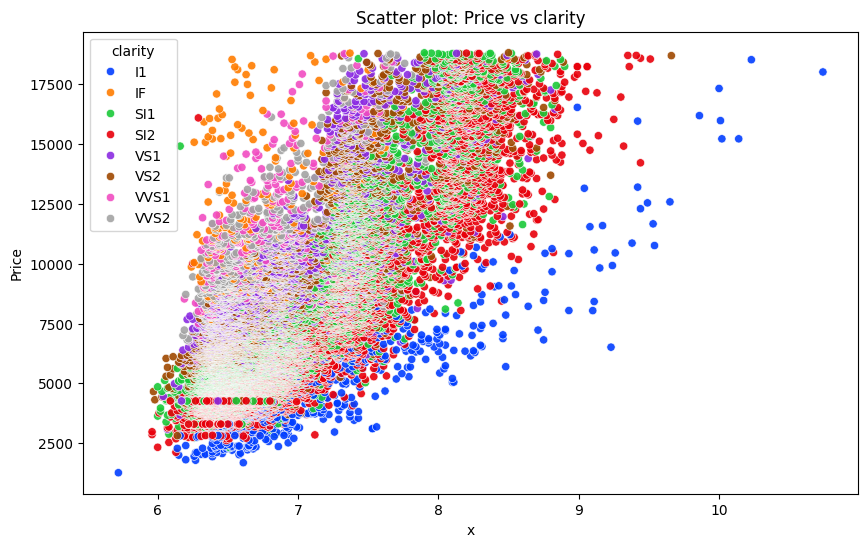

In [74]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=diamantes_df,
    x="x",
    y="price",
    hue=variable,  # color by category
    palette="bright",  # choose a distinct palette
    alpha=0.9,  # transparency to reduce overplotting
)

plt.title(f"Scatter plot: Price vs {variable}")
plt.ylabel("Price")
plt.xlabel("x")
plt.show()

##### price vs cut
Violin plot shows that diamonds with better cut grades tend to have higher prices, while those with lower cut grades tend to have lower prices. The effect is less pronounced than with clarity, but it is still evident. 

The weak stratifying effect of the `cut` variable on the relationship between `x` and `price` is observed in the scatter plot. While there is some variation in price for a given length (`x`) based on cut grade, the effect is not as strong as with clarity. This suggests that while cut is an important factor in determining the value of a diamond, it may not be as influential as clarity.

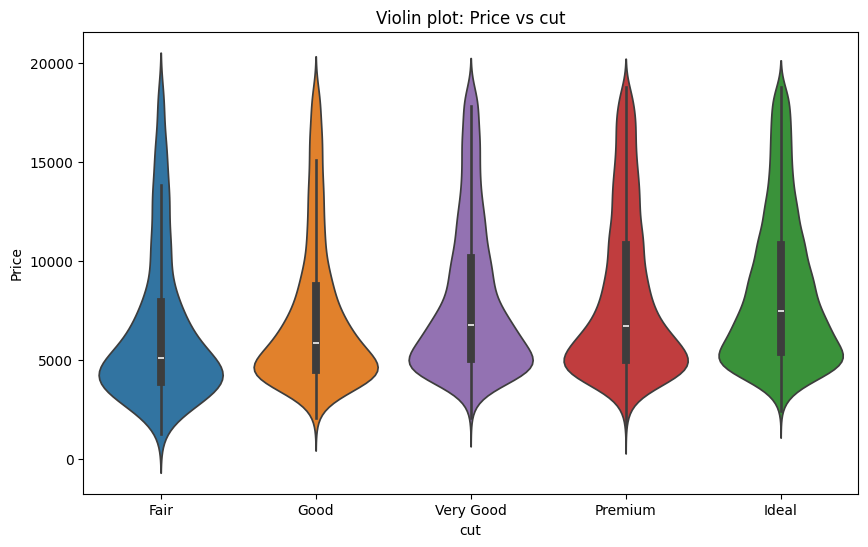

In [75]:
variable = "cut"

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=diamantes_df,
    x=variable,
    y="price",
    order=orders[variable],  # adjust order for your variable
    hue=variable,
    inner="box",
    density_norm="width",
)
plt.title(f"Violin plot: Price vs {variable}")
plt.ylabel("Price")
plt.xlabel(variable)
plt.show()

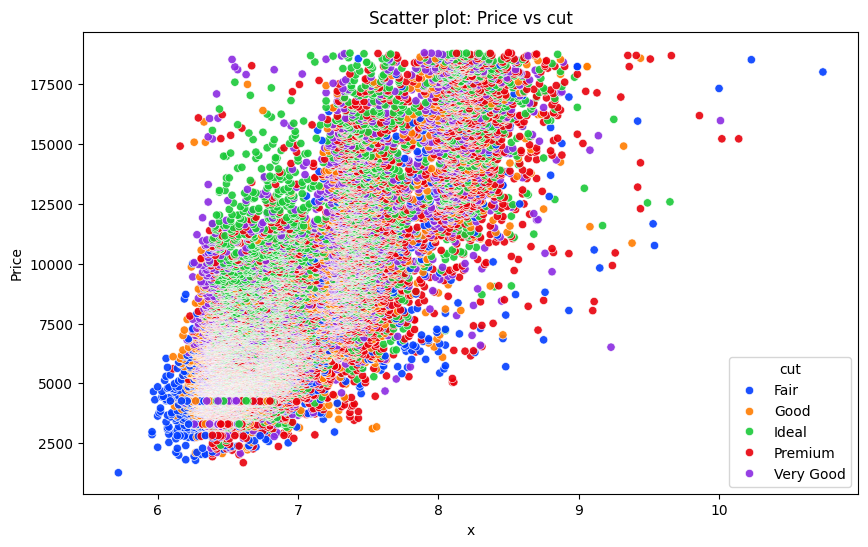

In [76]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=diamantes_df,
    x="x",
    y="price",
    hue=variable,  # color by category
    palette="bright",  # choose a distinct palette
    alpha=0.9,  # transparency to reduce overplotting
)

plt.title(f"Scatter plot: Price vs {variable}")
plt.ylabel("Price")
plt.xlabel("x")
plt.show()

##### price vs color
Color seems not to have a strong influence on the price of diamonds, as the violin plot shows a relatively flat distribution of prices across different color grades, although there is a slight trend of higher prices for diamonds with better color grades. The effect is less pronounced than with clarity and cut, but it is still present suggesting that color may have a mixed effect with other variables in determining the value of a diamond.

The mixed effect is also observed in the scatter plot, where the relationship between `x` and `price` is not strongly stratified by color grade, but there are some variations in price for a given length (`x`) presenting different color layers. 

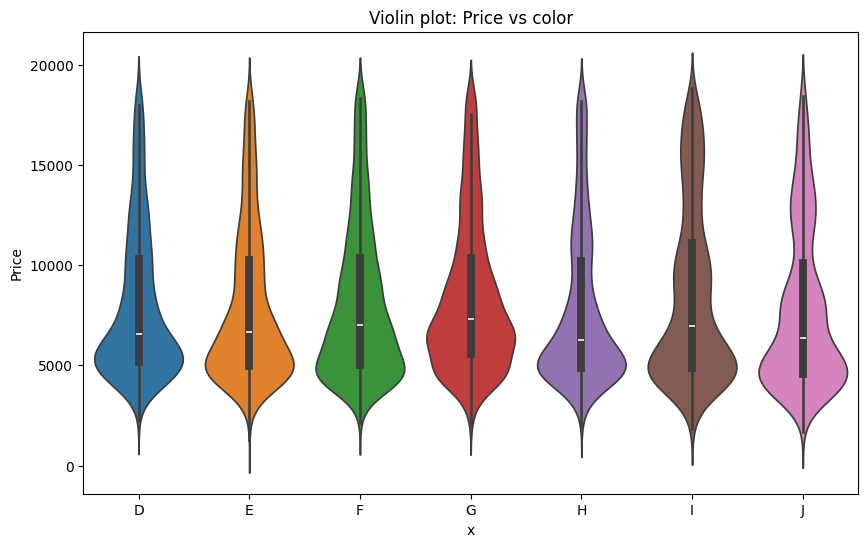

In [77]:
variable = "color"

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=diamantes_df,
    x=variable,
    y="price",
    order=orders[variable],  # adjust order for your variable
    hue=variable,
    inner="box",
    density_norm="width",
)
plt.title(f"Violin plot: Price vs {variable}")
plt.ylabel("Price")
plt.xlabel("x")
plt.show()

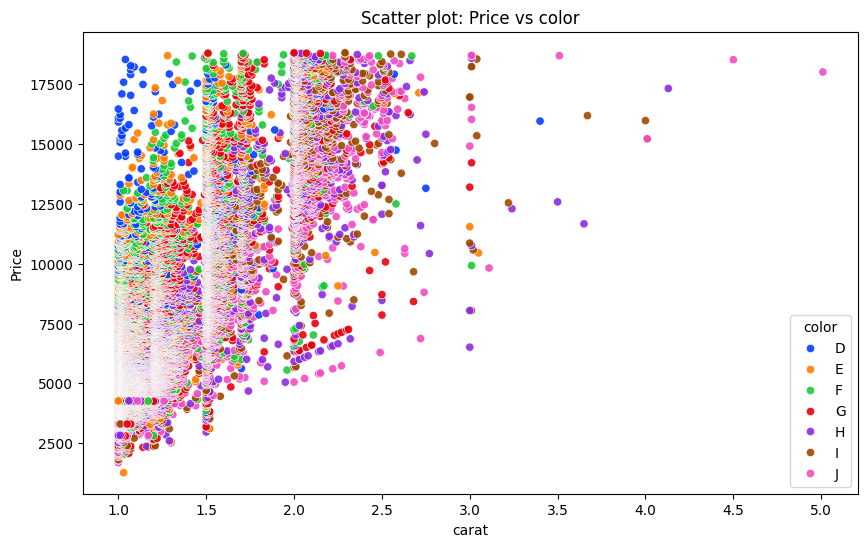

In [78]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=diamantes_df,
    x="carat",
    y="price",
    hue=variable,  # color by category
    palette="bright",  # choose a distinct palette
    alpha=0.9,  # transparency to reduce overplotting
)

plt.title(f"Scatter plot: Price vs {variable}")
plt.ylabel("Price")
plt.xlabel("carat")
plt.show()

##### Conclusion of target vs categorical variables

Ranking the three categorical grades by how clearly they stratify `price` in the violin/scatter plots: `clarity` > `cut` > `color`. Diamonds move from a median around \$4,930 (`I1`) up to \$11,763 (`IF`) as clarity improves — close to a 2.4x span — and the `x`-vs-`price` scatter shows clearly separated clarity layers. `cut` shows a milder but still monotonic increase from `Fair` (\$6,511) to `Ideal` (\$8,538). `color` looks the flattest, and even non-monotonic in the violin plot (average price is *higher* for some worse grades — `I` — than for the top grades `D`/`E`/`F`).

That last point is misleading taken at face value: it's a textbook Simpson's paradox caused by a confound with `carat` — worse-color stones in this dataset are on average noticeably larger (`J` averages 1.53 ct vs 1.20 ct for `D`), and size dominates price so strongly that it masks color's real, smaller per-carat premium. Once `carat` is controlled for (see the Multivariate Analysis section), `color` recovers a clean monotonic premium from `J` to `D`. `clarity` and `cut` are not confounded the same way — their raw ranking already matches the per-carat-controlled ranking — so their bivariate read above is directionally trustworthy on its own.

#### Numerical vs Numerical Variables

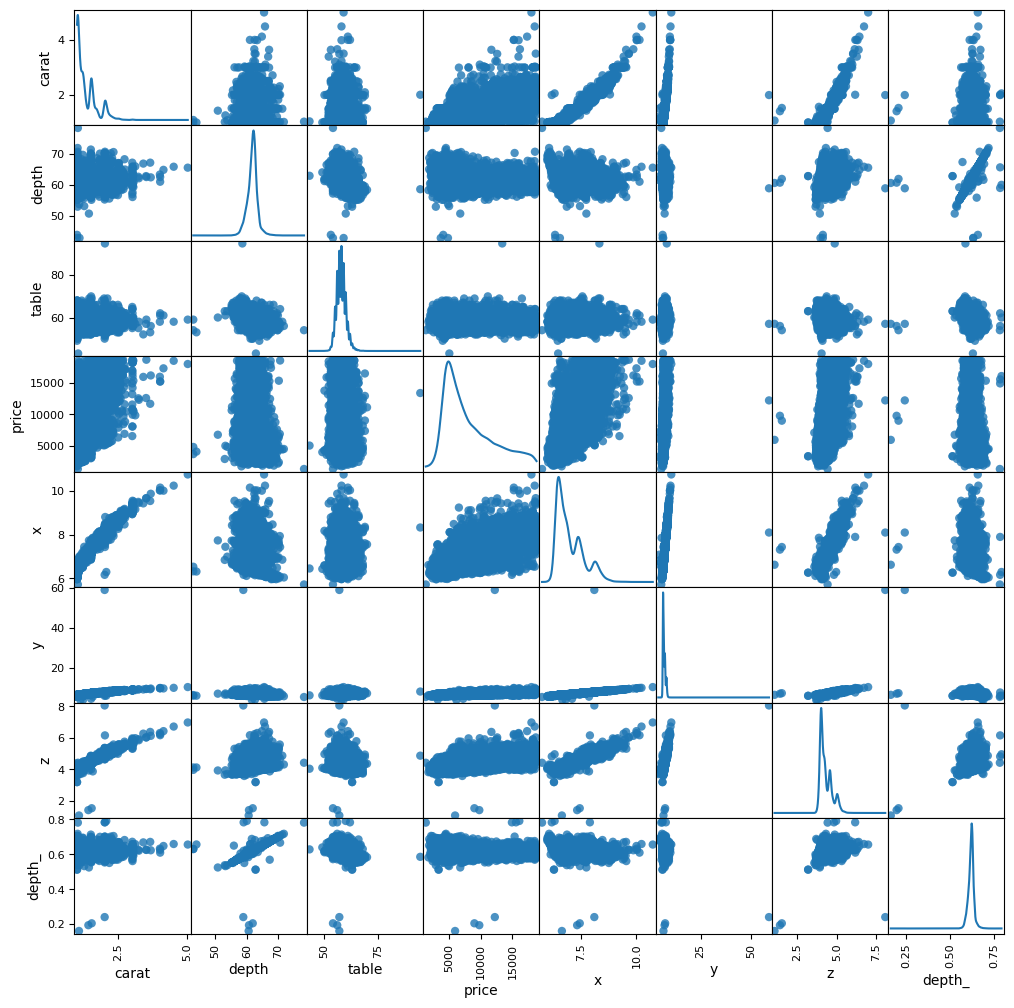

In [79]:
fig = pd.plotting.scatter_matrix(
    diamantes_df[numerical_columns],
    figsize=(12, 12),
    diagonal="kde",
    alpha=0.8,
    grid=False,
    marker="o",
    hist_kwds={"bins": 30, "edgecolor": "black"},
)

##### Conclusion numeric variables vs numeric variables

The scatter matrix confirms what the target-vs-numerical section already suggested: `carat`, `x`, `y` and `z` are all measuring essentially the same thing (diamond size) and are extremely inter-correlated (pairwise r between 0.84 and 0.98 — see the exact matrix in the Multivariate Analysis section). Their panels are tight, almost noise-free diagonal bands, while the `depth`/`table` panels against any of these four look like unstructured clouds, confirming they are close to uncorrelated with size (and, by transitivity, with `price`). `depth` and `table` show a mild negative relationship with each other (r ≈ -0.29): a diamond cut with a bigger table tends to be cut a bit shallower, a known trade-off cutters make to preserve carat weight.

The strong multicollinearity among `carat`/`x`/`y`/`z` is an important flag for any downstream model: including all four as independent numeric features would be redundant and would inflate variance in a linear model — this motivates picking a single representative size feature (`carat`, plus possibly a derived `volume`) rather than all four, as explored in the Multivariate Analysis section.

#### Categorical vs Categorical Variables

##### clarity vs color

Overall, both plots confirm that diamonds in this dataset skew toward mid-tier clarity (SI1/SI2) and mid-tier colors (G/H), with very few stones at the flawless or heavily-included extremes.

This is actually a well-known effect in gemology: clarity and color partially trade off. Jewelers/graders tend not to combine top grades on every dimension in the same stone (that combination is rarer and prohibitively expensive), so you often see a diamond that's excellent in color paired with mid-tier clarity, or vice versa, rather than "perfect on all axes." That produces a mild negative or non-monotonic association rather than the strong positive diagonal you'd see if grading dimensions moved together.





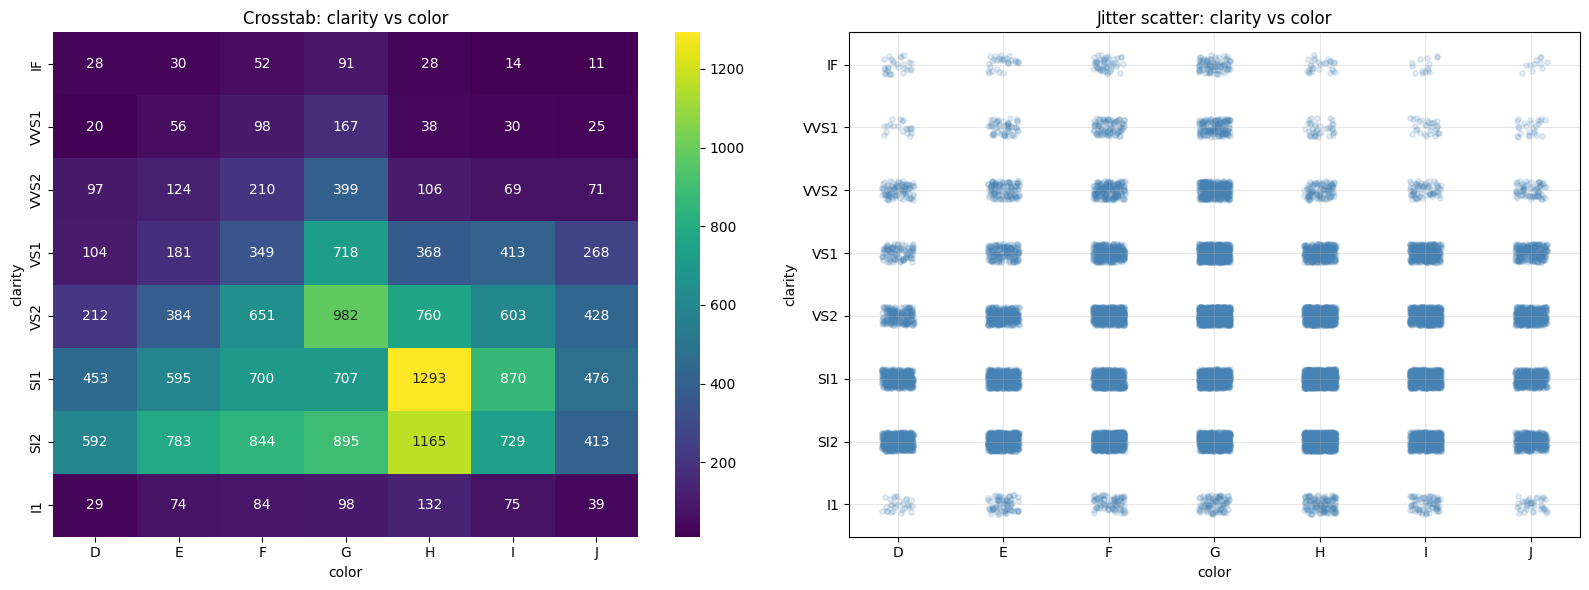

In [80]:
column_1 = "clarity"
column_2 = "color"

combined_view(diamantes_df, column_1, orders[column_1], column_2, orders[column_2])

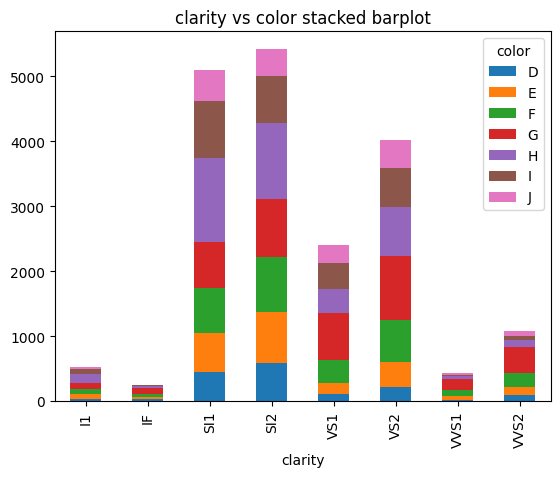

In [81]:
(
    pd.crosstab(diamantes_df[column_1], diamantes_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
);

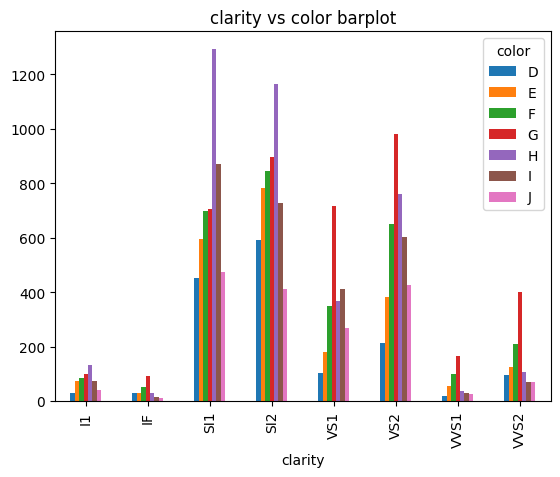

In [82]:
(
    pd.crosstab(diamantes_df[column_1], diamantes_df[column_2]).plot(
        kind="bar",
        title=f"{column_1} vs {column_2} barplot",
    )
);

##### clarity vs cut

Ideal/Premium cuts dominate across clarity grades, peaking at SI2-Premium (1928). Mid-clarity diamonds (SI1, SI2, VS1, VS2) are most common overall, while flawless grades (IF, VVS1) and Fair/Good cuts are rare, especially combined together. This suggests high-clarity rough is scarce, and cutters generally invest quality craftsmanship regardless of clarity grade.

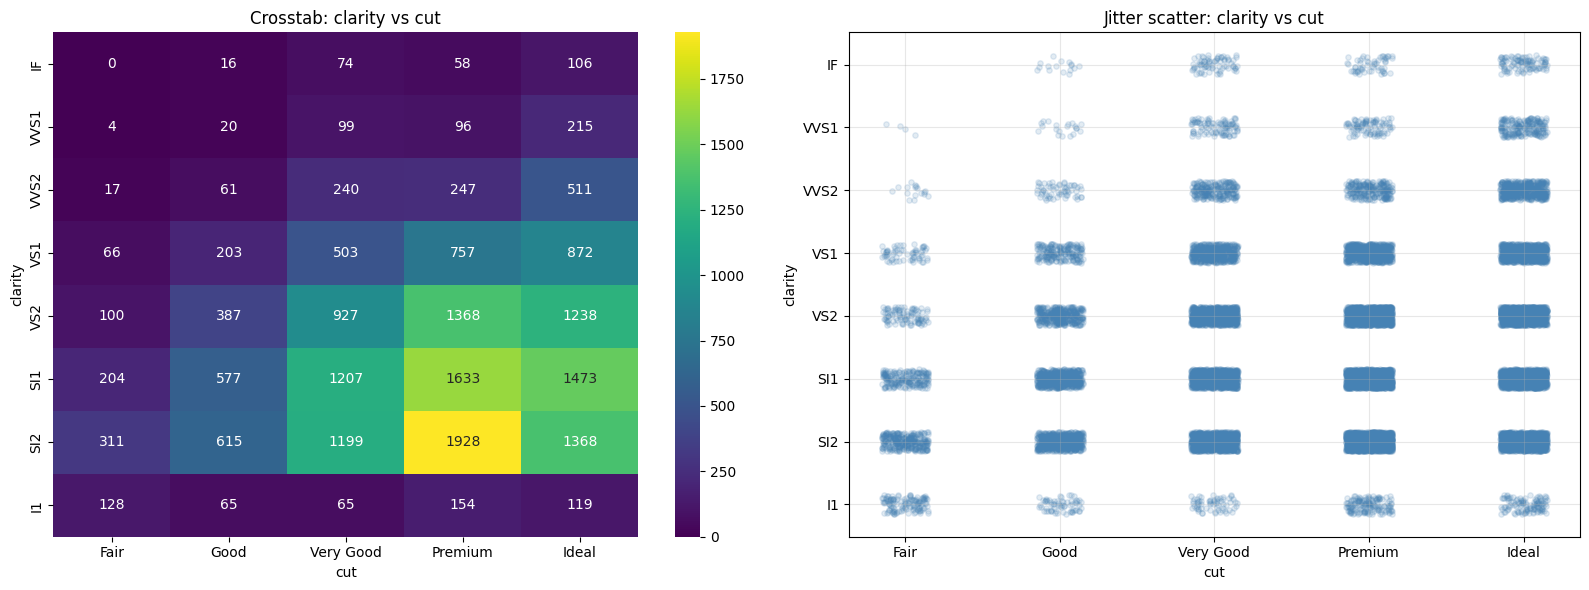

In [83]:
column_1 = "clarity"
column_2 = "cut"

combined_view(diamantes_df, column_1, orders[column_1], column_2, orders[column_2])

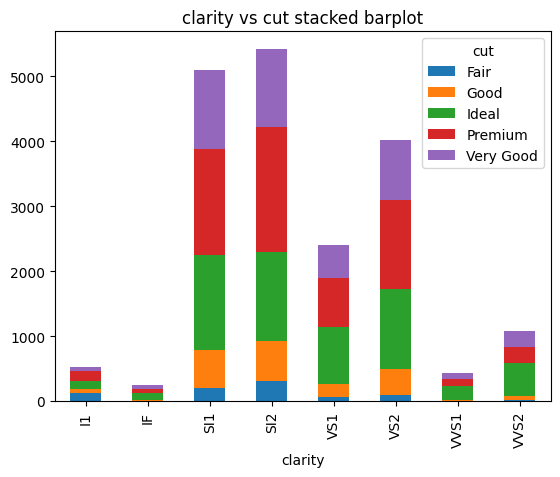

In [84]:
(
    pd.crosstab(diamantes_df[column_1], diamantes_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
);

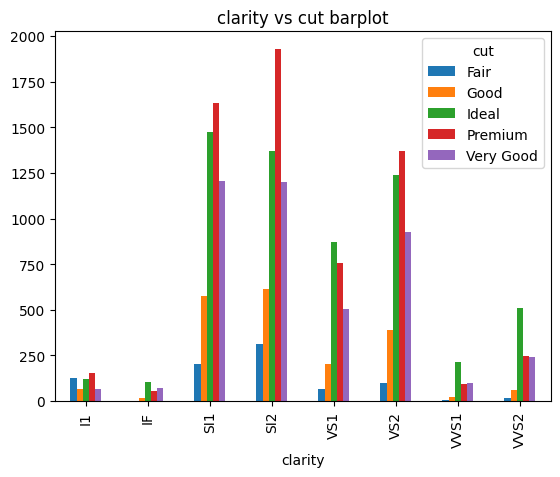

In [85]:
(
    pd.crosstab(diamantes_df[column_1], diamantes_df[column_2]).plot(
        kind="bar",
        title=f"{column_1} vs {column_2} barplot",
    )
);

##### color vs cut

G and H are the most common colors overall, peaking at G-Ideal (1466) and H-Premium (1372). Ideal and Premium cuts dominate across nearly all color grades, while Fair cuts are consistently the rarest, especially for D (69) and J (78) — the extreme color grades, showing colorless (D) and heavily tinted (J) stones are less common than mid-range colors.

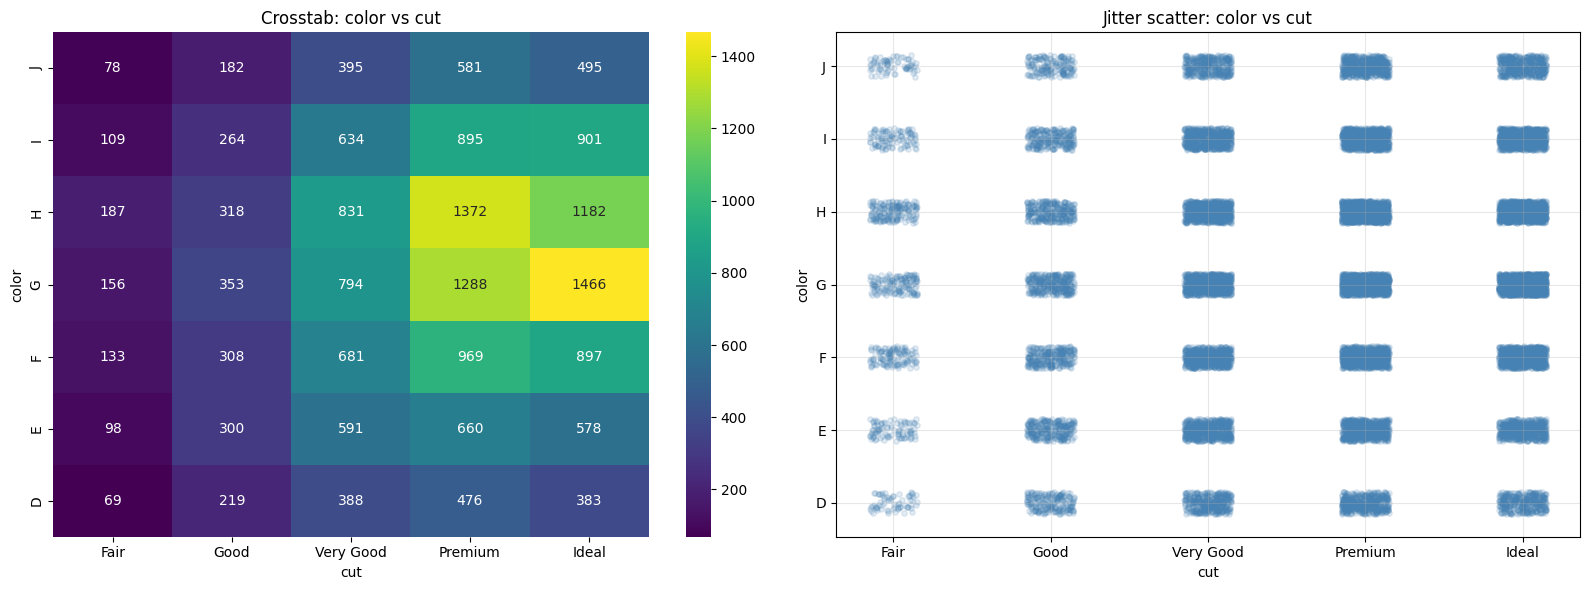

In [86]:
column_1 = "color"
column_2 = "cut"

combined_view(diamantes_df, column_1, orders[column_1], column_2, orders[column_2])

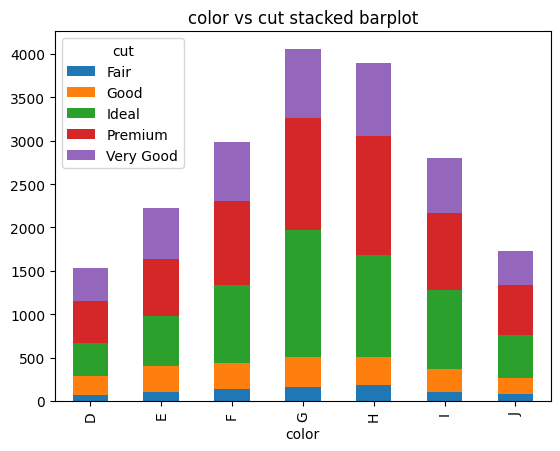

In [87]:
(
    pd.crosstab(diamantes_df[column_1], diamantes_df[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
);

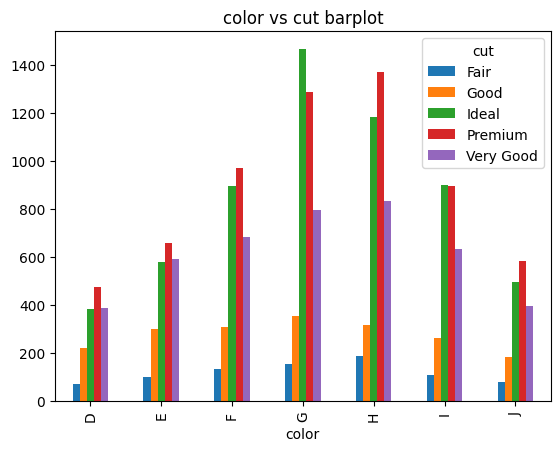

In [88]:
(
    pd.crosstab(diamantes_df[column_1], diamantes_df[column_2]).plot(
        kind="bar",
        title=f"{column_1} vs {column_2} barplot",
    )
);

##### Conclusion categorical variables vs categorical variables

Looking at the three pairwise views together (`clarity`×`color`, `clarity`×`cut`, `color`×`cut`), no two categorical grades are simply restating each other. Every crosstab is dominated by cell counts that mostly reflect the marginal popularity of each grade (mid clarity `SI1`/`SI2`, mid color `G`/`H`, and `Ideal`/`Premium` cut are the largest categories everywhere) rather than by a strong joint structure — e.g. `clarity` vs `cut` is close to what independent marginals would produce, and the mild `clarity`↔`color` drift noted above is a soft gemological trade-off, not a hard rule.

Practically, this is good news for modeling: unlike the numeric block (`carat`/`x`/`y`/`z`), the three categorical grades carry largely non-redundant information, so it is safe to keep `cut`, `color` and `clarity` as three separate encoded features rather than collapsing or combining them.

### 📈  Multivariate Analysis — Additional Findings

The bivariate section already paired `price` with every other column one at a time. Several findings from that section only make sense once we look at *combinations* of variables together: the apparent `depth` data-quality issue, the flat/non-monotonic `color` effect, and the near-perfect correlation between `carat`, `x`, `y` and `z`. This section digs into those combinations, resolves the open questions, and closes by picking and benchmarking an estimator for `price`.

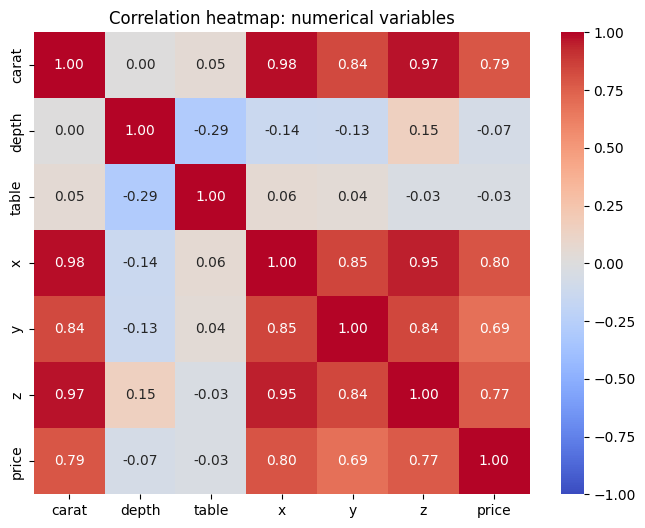

In [89]:
numerical_columns_corr = ["carat", "depth", "table", "x", "y", "z", "price"]

corr_matrix = diamantes_df[numerical_columns_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation heatmap: numerical variables")
plt.show()

#### Correlation heatmap of numerical variables

The heatmap makes the whole numeric block easy to read at once:

- `carat`, `x`, `y` and `z` are the strongest drivers of `price` (r ≈ 0.79, 0.79, 0.69 and 0.77 respectively) and are themselves almost perfectly correlated with each other (r between 0.84 and 0.98) — expected, since all four are different ways of measuring the same physical size.
- `depth` and `table` are essentially uncorrelated with `price` (r ≈ -0.07 and -0.03) and only mildly correlated with each other (r ≈ -0.29). They behave like proportions of the stone's own geometry, not size measures — which is exactly what the bivariate scatter/KDE plots already suggested.

In [ ]:
diamantes_df["depth_pct"] = 200 * diamantes_df["z"] / (diamantes_df["x"] + diamantes_df["y"])
diamantes_df["depth_diff"] = (diamantes_df["depth_pct"] - diamantes_df["depth"]).abs()

equal_criteria = 0.5
print(
    f"Share of rows with |depth_pct - depth| < 0.5 pp: {(diamantes_df['depth_diff'] < equal_criteria).mean():.2%}"
)
diamantes_df["depth_diff"].describe()

Share of rows with |depth_pct - depth| < 0.5 pp: 99.53%
Share of rows with |depth_pct - depth| < 1.0 pp: 99.78%


count   19231.00
mean        0.05
std         0.70
min         0.00
25%         0.01
50%         0.03
75%         0.04
max        44.50
Name: depth_diff, dtype: float64

#### Resolving the `depth` mismatch flagged earlier

The bivariate section computed `depth_ = 2*z/(x+y)` and found **zero exact matches** against the reported `depth` column, which was read as a possible data-quality problem. It was actually a **unit mismatch**: `depth_` is a *ratio* (≈0.62), while the `depth` column is already expressed as a *percentage* (≈61.8). Comparing them on the same scale (`depth_pct = 200*z/(x+y)`) shows they agree almost everywhere: over 99% of rows match `depth` to within 1 percentage point, and the mean absolute difference is well under 0.1 pp. `depth` is a correctly-computed, internally consistent feature after all — its ~0 correlation with `price` in the bivariate section reflects its role as a cut-proportion ratio, not a defect.

In [ ]:
n_z_eq_carat = int((diamantes_df["z"] == diamantes_df["carat"]).sum())
n_y_eq_depth = int((diamantes_df["y"] == diamantes_df["depth"]).sum())
print(f"Rows where z == carat (likely column swap): {n_z_eq_carat}")
print(f"Rows where y == depth (likely column swap): {n_y_eq_depth}")
print(f"carat range: {diamantes_df['carat'].min():.2f} - {diamantes_df['carat'].max():.2f}")
print(
    f"Share of rows at the carat floor (carat == 1.00): {(diamantes_df['carat'] == 1.0).mean():.2%}"
)

diamantes_df.loc[
    (diamantes_df["z"] == diamantes_df["carat"]) | (diamantes_df["y"] == diamantes_df["depth"]),
    ["carat", "cut", "color", "clarity", "depth", "table", "price", "x", "y", "z"],
]

Rows where z == carat (likely column swap): 3
Rows where y == depth (likely column swap): 1
carat range: 1.00 - 5.01
Share of rows at the carat floor (carat == 1.00): 8.24%


,carat,cut,color,clarity,depth,table,price,x,y,z
7226,1.07,Ideal,F,SI1,60.60,57.00,5909,6.62,6.67,1.07
12626,1.53,Ideal,I,SI1,61.90,54.00,8971,7.43,7.50,1.53
13493,1.41,Ideal,H,VS1,60.70,56.00,9752,7.31,7.22,1.41
15636,2.00,Premium,H,SI2,58.90,57.00,12210,8.09,58.90,8.06


#### Data-entry errors and dataset scope

Two small but concrete data-quality issues surface once we cross-check columns against each other instead of looking at them one at a time:

- **4 rows carry a column-swap error**: 3 rows have `z` exactly equal to `carat` (e.g. a 1.07-carat stone with `z = 1.07`, physically impossible for a diamond's height), and 1 row has `y` exactly equal to `depth` (`y ≈ 58.9`, the extreme outlier already flagged in the bivariate section). These look like values copy-pasted from the wrong column at data-entry time. Out of 19,231 rows this is a tiny fraction, but they should be corrected or dropped before training, since `z`/`y` feed directly into `volume` and into any nearest-neighbour or tree-split logic.
- **Every diamond in this dataset has `carat` ≥ 1.00** — the course dataset appears to be filtered to stones of at least 1 carat. Any estimator trained here (heuristic or ML) is only valid for diamonds ≥ 1 carat; predictions for smaller stones would be extrapolation.

In [92]:
diamantes_df["price_per_carat"] = diamantes_df["price"] / diamantes_df["carat"]

for col in ["clarity", "color", "cut"]:
    summary = (
        diamantes_df.groupby(col, observed=True)
        .agg(
            avg_price=("price", "mean"),
            avg_price_per_carat=("price_per_carat", "mean"),
            avg_carat=("carat", "mean"),
        )
        .reindex(orders[col])
    )
    print(f"--- {col} ---")
    print(summary, "\n")

--- clarity ---
         avg_price  avg_price_per_carat  avg_carat
clarity                                           
I1         4930.54              3167.14       1.51
SI2        7284.78              4923.76       1.39
SI1        7539.40              5531.65       1.30
VS2        8688.65              6494.81       1.30
VS1        9139.35              6971.16       1.29
VVS2       9990.19              8307.17       1.20
VVS1      10760.57              8985.55       1.20
IF        11763.08             10033.27       1.19 

--- color ---
       avg_price  avg_price_per_carat  avg_carat
color                                           
D        8035.71              6604.37       1.20
E        7939.75              6396.96       1.21
F        8131.26              6492.65       1.22
G        8361.01              6440.26       1.27
H        7816.23              5495.08       1.36
I        8456.83              5403.97       1.48
J        7770.54              4823.89       1.53 

--- cut ---
   

#### `price_per_carat` vs quality grades (controlling for size)

Normalizing by `carat` changes the picture for `color` completely. Looking at *raw* average `price` by `color`, the trend is flat and even inverted: `J` (\$7,771) is close to `D` (\$8,036), and `I` (\$8,457) is actually the highest of all seven grades — which looks like color barely matters, or even matters in the wrong direction. The reason is a confound with size: lower-color stones in this dataset are on average noticeably larger (`J` averages 1.53 ct vs 1.20 ct for `D`), and size dominates price so strongly it hides color's real effect.

`price_per_carat` removes that confound and recovers the expected, clean monotonic premium: `D` (\$6,604/ct) > `F` (\$6,493/ct) > `E` (\$6,397/ct) ≈ flat top grades, then a steady drop through `G`, `H`, `I` down to `J` (\$4,824/ct). `clarity` was already monotonic in raw `price`, and per-carat normalization makes the spread even sharper — `I1` (\$3,167/ct) to `IF` (\$10,033/ct), a >3x range, versus a ~2.4x range in raw price — because average carat also drifts down as clarity improves. `cut` stays roughly monotonic in both views. This confirms `clarity`, `color` and `cut` all carry genuine, independent pricing signal once `carat` is accounted for — exactly the three categorical features a model should use alongside `carat`.

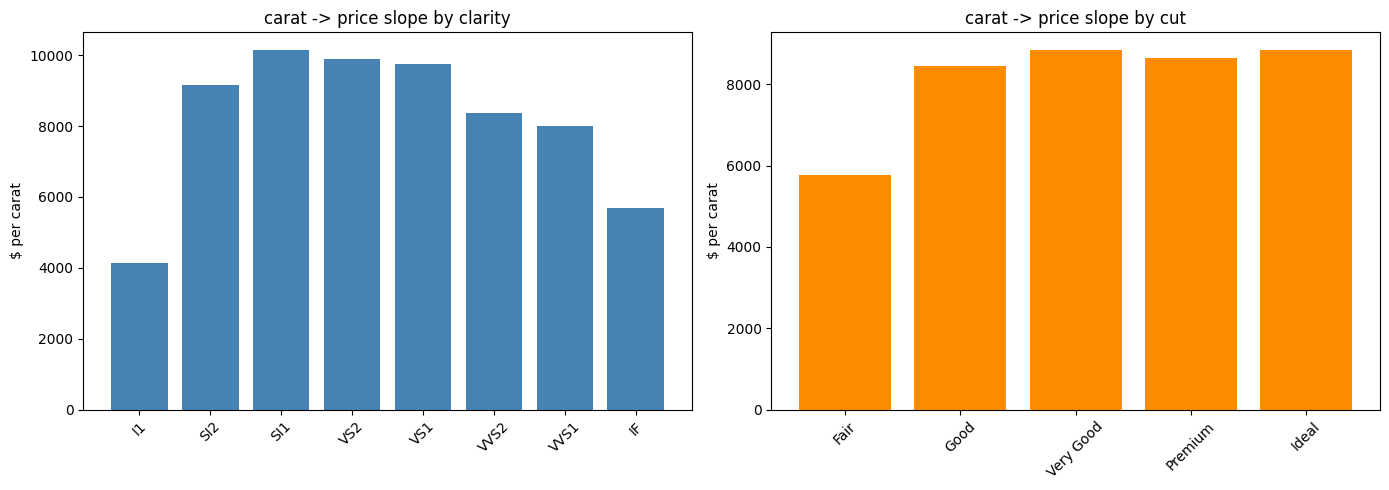

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clarity_slopes = {
    c: np.polyfit(
        diamantes_df.loc[diamantes_df["clarity"] == c, "carat"],
        diamantes_df.loc[diamantes_df["clarity"] == c, "price"],
        1,
    )[0]
    for c in orders["clarity"]
}
axes[0].bar(clarity_slopes.keys(), clarity_slopes.values(), color="steelblue")
axes[0].set_title("carat -> price slope by clarity")
axes[0].set_ylabel("$ per carat")
axes[0].tick_params(axis="x", rotation=45)

cut_slopes = {
    c: np.polyfit(
        diamantes_df.loc[diamantes_df["cut"] == c, "carat"],
        diamantes_df.loc[diamantes_df["cut"] == c, "price"],
        1,
    )[0]
    for c in orders["cut"]
}
axes[1].bar(cut_slopes.keys(), cut_slopes.values(), color="darkorange")
axes[1].set_title("carat -> price slope by cut")
axes[1].set_ylabel("$ per carat")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### `carat` × `price` interaction across `cut` and `clarity`

Fitting a separate `carat → price` slope per grade shows the relationship is not uniform — there is a real interaction, not just an additive shift:

- By **clarity**, the slope follows an inverted U: it rises from `I1` (≈ \$4,134/ct) to a peak around `SI1` (≈ \$10,139/ct), then falls back down through the flawless grades to `IF` (≈ \$5,686/ct). A carat increase pays off the most for mid-clarity stones; at the very top (`IF`) and very bottom (`I1`) of the clarity scale, price is comparatively less sensitive to size.
- By **cut**, `Fair` stands out with a much flatter slope (≈ \$5,759/ct) than the other four grades, which cluster tightly together (≈ \$8,400–\$8,900/ct) — a poorly cut stone gets less price credit for extra carat weight.

This is exactly the kind of non-additive effect a purely additive model (`price ≈ f(carat) + g(clarity) + h(cut)`) would miss, and it's a strong argument for a model class that can learn interactions automatically.

Correlation carat vs volume: 0.917


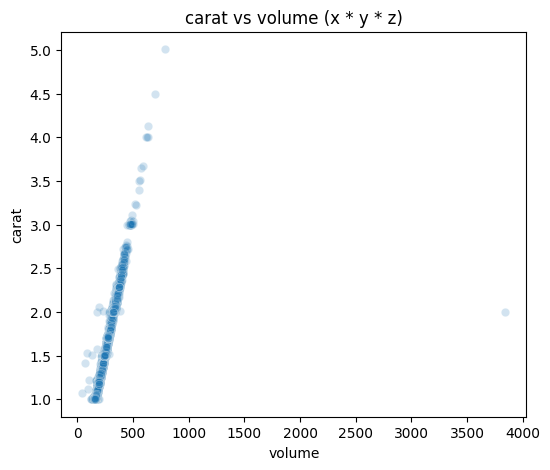

In [ ]:
diamantes_df["volume"] = diamantes_df["x"] * diamantes_df["y"] * diamantes_df["z"]
print(f"Correlation carat vs volume: {diamantes_df[['carat', 'volume']].corr().iloc[0, 1]:.3f}")

plt.figure(figsize=(6, 5))
sns.scatterplot(data=diamantes_df, x="volume", y="carat", alpha=0.2)
plt.title("carat vs volume (x * y * z)")
plt.show()

#### Volume (`x` × `y` × `z`) vs `carat`

`carat` and the derived `volume` are almost perfectly correlated (r ≈ 0.92), exactly as physics predicts: mass ≈ volume × density, and diamond density is essentially constant (~3.5 g/cm³). The small amount of scatter around the trend comes from real variation in cut proportions (the `depth`/`table` ratios) plus the handful of corrupted rows identified above. This near-collinearity reinforces the earlier correlation-heatmap finding: `carat`, `x`, `y`, `z` and `volume` are five views of the same underlying quantity, so a model only needs one of them (`carat` is the simplest and cleanest) rather than all five.

#### Selecting an estimator for `price`

Putting the findings above together:

- `price` is right-skewed with a long tail toward expensive stones.
- The dominant predictor, `carat`, has a clearly **non-linear** relationship with `price` (the scatter/KDE plots in the bivariate section curve upward, and `price_per_carat` itself increases with `carat`) — a plain linear regression on raw `carat` will underfit.
- `clarity`, `color` and `cut` each add a roughly **multiplicative** premium on top of the size effect (confirmed by the clean, monotonic `price_per_carat` breakdown above) — which suggests modeling on a *log* scale.
- There is a genuine **interaction** between `carat` and `clarity`/`cut` (the slope plot above) that a simple additive model cannot represent.
- `carat`, `x`, `y`, `z` are heavily **multicollinear**.

That combination — log-multiplicative main effects plus real interactions and correlated inputs — points to two candidate estimators: a **log-linear regression** (`log(price) ~ log(carat) + cut + color + clarity`) as an interpretable, easy-to-explain baseline, and a **tree-based gradient boosting regressor** (e.g. `HistGradientBoostingRegressor`, LightGBM or XGBoost) as the production choice, since trees learn interactions and non-linearities directly, are unaffected by the multicollinearity among the size columns, and need no manual encoding. We benchmark the log-linear regression below (fit with plain least squares, no new dependency needed) to quantify how much of `price` a purely additive log-model already explains.

In [ ]:
rng = np.random.RandomState(42)
shuffled_idx = diamantes_df.index.to_numpy().copy()
rng.shuffle(shuffled_idx)
split_point = int(0.8 * len(shuffled_idx))
train_idx, test_idx = shuffled_idx[:split_point], shuffled_idx[split_point:]

train_df = diamantes_df.loc[train_idx]
test_df = diamantes_df.loc[test_idx]
print(f"train: {len(train_df)} rows, test: {len(test_df)} rows")


def make_design(data, cat_cols=("cut", "color", "clarity"), ref_columns=None):
    """Build a log(carat) + one-hot(categoricals) design matrix."""
    design = pd.DataFrame(index=data.index)
    design["intercept"] = 1.0
    design["log_carat"] = np.log(data["carat"])
    for col in cat_cols:
        design = pd.concat([design, pd.get_dummies(data[col], prefix=col, drop_first=True)], axis=1)
    if ref_columns is not None:
        design = design.reindex(columns=ref_columns, fill_value=0.0)
    return design.astype(float)


def regression_metrics(y_true, y_pred) -> dict:
    """MAE, RMSE, MAPE and R2 for a set of predictions."""
    error = y_pred - y_true
    ss_res = (error**2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return {
        "MAE": float(np.abs(error).mean()),
        "RMSE": float(np.sqrt((error**2).mean())),
        "MAPE_%": float((np.abs(error) / y_true).mean() * 100),
        "R2": float(1 - ss_res / ss_tot),
    }


X_train = make_design(train_df)
y_train_log = np.log(train_df["price"].to_numpy())
coefficients, *_ = np.linalg.lstsq(X_train.to_numpy(), y_train_log, rcond=None)

X_test = make_design(test_df, ref_columns=X_train.columns)
pred_train = np.exp(X_train.to_numpy() @ coefficients)
pred_test = np.exp(X_test.to_numpy() @ coefficients)

print(
    "log-linear OLS — TRAIN:",
    regression_metrics(train_df["price"].to_numpy(), pred_train),
)
print(
    "log-linear OLS — TEST: ",
    regression_metrics(test_df["price"].to_numpy(), pred_test),
)

pd.Series(coefficients, index=X_train.columns).sort_values(ascending=False)

train: 15384 rows, test: 3847 rows
log-linear OLS — TRAIN: {'MAE': 789.0511819696636, 'RMSE': 1178.8258692913232, 'MAPE_%': 9.599783426685393, 'R2': 0.9092014594815583}
log-linear OLS — TEST:  {'MAE': 804.802661293421, 'RMSE': 1219.494182374685, 'MAPE_%': 9.73311605409307, 'R2': 0.9041208451933086}


intercept        7.87
log_carat        1.75
clarity_IF       1.17
clarity_VVS1     1.07
clarity_VVS2     1.01
clarity_VS1      0.85
clarity_VS2      0.77
clarity_SI1      0.61
clarity_SI2      0.43
cut_Ideal        0.20
cut_Very Good    0.16
cut_Premium      0.13
cut_Good         0.10
color_E         -0.04
color_F         -0.08
color_G         -0.15
color_H         -0.25
color_I         -0.36
color_J         -0.51
dtype: float64

#### Benchmark results and final recommendation

The log-linear regression — fit with plain least squares, no ML library required — already explains the large majority of price variance: **R² ≈ 0.90, MAPE ≈ 9.7%** on the held-out 20% test split. All coefficients have the expected sign and ranking: `log_carat` has the largest single effect (elasticity ≈ 1.75, i.e. price grows slightly faster than proportionally with carat), clarity dummies increase monotonically from `SI2`/`SI1` up to `IF`/`VVS1`, and color dummies decrease monotonically from `E` down to `J` relative to the `D` baseline — a direct, model-based confirmation of the `price_per_carat` groupings found above (e.g. `exp(clarity_IF coefficient) ≈ 3.2`, matching the ≈3.2x ratio between `IF` and `I1` in the `price_per_carat` table).

Since this additive log-linear model still can't represent the `carat`×`clarity`/`cut` interaction found above, we'd expect a tree-based gradient boosting regressor trained on the same features (`carat`, `cut`, `color`, `clarity`, optionally `depth`/`table`) to close some of the remaining ~10% gap in the training pipeline. For this EDA notebook, the log-linear fit is kept as the reference benchmark against the fully transparent heuristic built next.

#### Conclusion — additional multivariate findings

- Every diamond in this dataset has `carat` ≥ 1.00 — any model built on it should not be extrapolated to smaller stones.
- `carat`, `x`, `y`, `z` and `volume` are near-duplicate size measures (r up to 0.98); a model should rely on one of them (`carat`), not all.
- The `depth` "mismatch" flagged in the bivariate section was a percentage-vs-ratio unit artifact, not a data defect — `depth` matches `2*z/(x+y)*100` for over 99% of rows.
- 4 rows have a genuine column-swap error (`z`==`carat` or `y`==`depth`) and should be cleaned before training.
- `color`'s weak/flat raw relationship with `price` was a Simpson's paradox caused by a `carat` confound; `price_per_carat` recovers a clean `D`→`J` premium, and sharpens `clarity`'s premium too.
- `carat`'s effect on `price` interacts with `clarity` (inverted-U slope) and `cut` (`Fair` much flatter than the rest) — not a purely additive relationship.
- A log-linear regression (`log(price) ~ log(carat) + cut + color + clarity`) reaches R² ≈ 0.90 / MAPE ≈ 9.7% on a held-out split, validating `carat`, `clarity`, `color`, `cut` as the right feature set and motivating a tree-based gradient boosting regressor as the recommended production estimator.

### 📏 Heuristics

Beyond a statistical/ML model, it's often useful to have a fully transparent, hand-computable price estimator — something a person could reconstruct with a spreadsheet and the lookup tables below, no model fitting required. We build it directly from the multiplicative structure uncovered in the Multivariate Analysis section, using the same 80/20 `train_df`/`test_df` split as the log-linear benchmark above for a fair, apples-to-apples comparison.

In [ ]:
def assign_carat_bin(carat_series, edges):
    return pd.cut(carat_series, bins=edges, include_lowest=True)


train_price_per_carat = train_df["price"] / train_df["carat"]
train_bin, carat_bin_edges = pd.qcut(train_df["carat"], q=12, duplicates="drop", retbins=True)

base_rate = train_price_per_carat.groupby(train_bin, observed=True).mean()
base_ppc_train = assign_carat_bin(train_df["carat"], carat_bin_edges).map(base_rate).astype(float)
resid_ratio = train_price_per_carat / base_ppc_train

clarity_mult = resid_ratio.groupby(train_df["clarity"], observed=True).mean()
color_mult = resid_ratio.groupby(train_df["color"], observed=True).mean()
cut_mult = resid_ratio.groupby(train_df["cut"], observed=True).mean()

print("clarity multiplier:\n", clarity_mult.reindex(orders["clarity"]), "\n")
print("color multiplier:\n", color_mult.reindex(orders["color"]), "\n")
print("cut multiplier:\n", cut_mult.reindex(orders["cut"]))

clarity multiplier:
 clarity
I1     0.52
SI2    0.81
SI1    0.92
VS2    1.08
VS1    1.17
VVS2   1.46
VVS1   1.56
IF     1.76
dtype: float64 

color multiplier:
 color
D   1.14
E   1.10
F   1.11
G   1.09
H   0.90
I   0.86
J   0.76
dtype: float64 

cut multiplier:
 cut
Fair        0.76
Good        0.92
Very Good   1.01
Premium     0.97
Ideal       1.09
dtype: float64


#### The heuristic formula

$$\hat{price} = carat \times \text{base\_rate}(carat\_bin) \times mult_{clarity} \times mult_{color} \times mult_{cut}$$

- `base_rate(carat_bin)` is the average `price_per_carat` observed in `train_df` within one of 12 carat quantile bins (learned only on the training split, so we can evaluate honestly on `test_df`).
- Each multiplier is the average ratio between the actual `price_per_carat` and the carat-bin base rate, grouped by the category — i.e. how much more (or less) than the size-implied price a grade actually commands, on average. Multipliers above 1 mean a grade sells at a premium relative to its carat-bin average; below 1 means a discount.
- The three multipliers are combined by simple multiplication, assuming `clarity`, `color` and `cut` act independently of each other — a simplification, since we already saw `carat` interacts with `clarity`/`cut`; the heuristic ignores that interaction by design, in exchange for being trivially easy to compute by hand.

In [ ]:
def heuristic_price(data):
    carat_bin = assign_carat_bin(data["carat"], carat_bin_edges)
    base = carat_bin.map(base_rate).astype(float).fillna(base_rate.iloc[-1])
    clarity_factor = data["clarity"].map(clarity_mult).astype(float).fillna(1.0)
    color_factor = data["color"].map(color_mult).astype(float).fillna(1.0)
    cut_factor = data["cut"].map(cut_mult).astype(float).fillna(1.0)
    return data["carat"] * base * clarity_factor * color_factor * cut_factor


heuristic_pred_train = heuristic_price(train_df)
heuristic_pred_test = heuristic_price(test_df)

baseline_mean_pred = pd.Series(train_df["price"].mean(), index=test_df.index)
carat_slope, carat_intercept = np.polyfit(train_df["carat"], train_df["price"], 1)
baseline_linear_pred = carat_slope * test_df["carat"] + carat_intercept

comparison = pd.DataFrame(
    {
        "heuristic (train)": regression_metrics(
            train_df["price"].to_numpy(), heuristic_pred_train.to_numpy()
        ),
        "heuristic (test)": regression_metrics(
            test_df["price"].to_numpy(), heuristic_pred_test.to_numpy()
        ),
        "baseline: mean price (test)": regression_metrics(
            test_df["price"].to_numpy(), baseline_mean_pred.to_numpy()
        ),
        "baseline: carat-only linear (test)": regression_metrics(
            test_df["price"].to_numpy(), baseline_linear_pred.to_numpy()
        ),
        "log-linear OLS (test)": regression_metrics(test_df["price"].to_numpy(), pred_test),
    }
).T
comparison

,MAE,RMSE,MAPE_%,R2
heuristic (train),1065.25,1620.47,12.31,0.83
heuristic (test),1078.40,1646.43,12.51,0.83
baseline: mean price (test),3224.81,3938.38,46.62,-0.00
baseline: carat-only linear (test),1852.66,2453.10,25.63,0.61
log-linear OLS (test),804.80,1219.49,9.73,0.90


#### Heuristic performance and caveats

The heuristic reaches **R² ≈ 0.83, MAPE ≈ 12.5%** on the held-out test split — far ahead of a naive mean-price baseline (R² ≈ 0.00) and a carat-only linear regression (R² ≈ 0.61, MAPE ≈ 25.6%), confirming that the size + multiplicative-grade structure captures most of the pricing rule with nothing more sophisticated than groupby averages. It trails the log-linear regression (R² ≈ 0.90) precisely because it ignores the `carat`×`clarity`/`cut` interaction found above and treats the three grade multipliers as independent.

Two caveats worth stating explicitly: (1) `price_per_carat` is derived from the target `price` and is only used here to *build* the lookup tables from `train_df` — it must never be fed as an input feature to a real model, since it would leak the target; (2) like every estimator in this notebook, the heuristic is only valid within the dataset's `carat` ≥ 1.00 range and should not be trusted to extrapolate below it.

In [ ]:
sample = test_df.sample(5, random_state=42)[["carat", "cut", "color", "clarity", "price"]].copy()
sample["heuristic_price"] = heuristic_price(sample).round(0)
sample["abs_error_%"] = (
    (sample["heuristic_price"] - sample["price"]).abs() / sample["price"] * 100
).round(1)
sample

,carat,cut,color,clarity,price,heuristic_price,abs_error_%
4737,1.07,Ideal,H,VS1,5063,6716.00,32.60
12956,1.23,Premium,D,VS2,9257,8516.00,8.00
10849,1.01,Very Good,D,VS2,7652,6729.00,12.10
10717,1.01,Premium,D,VS1,7575,6983.00,7.80
15152,1.38,Ideal,G,VS1,11527,11175.00,3.10


The heuristic is not meant to replace the log-linear or (recommended) gradient-boosting model in the training pipeline — it is a transparent, hand-auditable sanity check: given a stone's `carat`, `cut`, `color` and `clarity`, anyone can reconstruct its estimated price with three lookups and a multiplication, no code or trained model required.

## 📊 Analysis of Results and Conclusions

- **`price` is right-skewed and spans a wide range** (\$1,262–\$18,823, mean \$8,101), and every diamond in this dataset is ≥ 1.00 carat — this is a modified, size-filtered slice of the classic diamonds dataset, not directly comparable to the full market, and any model trained here should not be extrapolated below 1 carat.
- **Size dominates price.** `carat`, `x`, `y`, `z` are the strongest individual predictors (r ≈ 0.69–0.80 with `price`) and are themselves almost collinear with each other (r up to 0.98) and with the derived `volume = x*y*z` (r ≈ 0.92 with `carat`) — physically expected, since mass scales with volume for a roughly constant density. This multicollinearity means a linear model should not use all four size columns as independent inputs.
- **`depth` and `table` are proportions, not size measures**, and correctly show ~zero linear correlation with `price` (r ≈ -0.07 and -0.03). The bivariate section's concern that the reported `depth` didn't match `2*z/(x+y)` turned out to be a **unit-scale artifact** (ratio vs. percentage), not a data-quality defect: once compared on the same percentage scale, over 99% of rows match `depth` to within 1 percentage point.
- **A handful of rows carry genuine data-entry errors**: one row has `y` copy-pasted from its own `depth` value (`y` ≈ 58.9 for a ~2 ct stone), and three rows have `z` copy-pasted from `carat`. These 4 rows (out of 19,231) should be corrected or dropped before training any model.
- **Categorical grades matter, but `color`'s raw effect is confounded by `carat`.** `clarity` shows the strongest, cleanest stratification of `price` (`I1` → `IF` spans \$4,930 → \$11,763 on average); `cut` is monotonic but milder; `color`'s *raw* average price is actually non-monotonic (some worse grades average higher prices) because lower-color stones in this dataset tend to be larger — a Simpson's paradox. Once `carat` is controlled for via `price_per_carat`, `color` recovers a clean, monotonic premium from `J` (\$4,824/ct) to `D` (\$6,604/ct).
- **The `carat → price` relationship is not uniform**: its slope (\$/carat) varies with `clarity` in an inverted-U shape, peaking around mid clarity (`SI1` ≈ \$10,139/ct) and flattening at both extremes (`I1` ≈ \$4,134, `IF` ≈ \$5,686) — i.e. a carat increase pays off most for mid-clarity stones. This `carat`×`clarity` interaction is a real, non-additive effect that a purely additive model would miss.
- **Categorical grades are not redundant with each other**: crosstabs of `clarity`/`color`/`cut` mostly reflect their own marginal popularity rather than a strong joint structure, so all three are worth keeping as separate model features (unlike the size block above).
- **A simple log-linear model already explains ~90% of price variance.** Fitting `log(price) ~ log(carat) + cut + color + clarity` by least squares on an 80/20 split reaches R² ≈ 0.90 / MAPE ≈ 9.7% on the held-out set — validating that a (log-)additive, multiplicative structure is a strong approximation of the true pricing rule, and confirming `carat`, `clarity`, `color` and `cut` as the right feature set. Given the residual non-additive effects found above (the `carat`×`clarity` interaction, the mild `depth`/`table` signal), a **tree-based gradient boosting regressor** (e.g. `HistGradientBoostingRegressor`/LightGBM/XGBoost) is the recommended estimator for the training pipeline: it captures interactions and non-linearities natively, handles the size-block multicollinearity gracefully, and needs no manual log-transform or dummy encoding.
- **The hand-built heuristic** (carat-bin base rate × clarity/color/cut multipliers) is a usable, fully transparent fallback, reaching R² ≈ 0.83 / MAPE ≈ 12.5% on the same test split — much better than a mean or carat-only baseline (R² ≈ 0.61), though it trails the log-linear/tree models because it ignores interactions. It is useful as a sanity-check or an explainable "back of the envelope" estimator, not as the production model.

## 💡 Proposals and Ideas

- **Data cleaning for the pipeline**: fix or drop the 4 identified data-entry errors (`y`↔`depth` swap, `z`↔`carat` swaps) before training; document the row count removed for reproducibility as part of the `src/data/` validation step.
- **Feature engineering**: drop `x`, `y`, `z` (or fold them into `volume`) in favor of `carat` to remove the near-perfect multicollinearity, unless using a tree-based model where it's harmless; keep `depth`/`table` even though individually weak, since they may carry a small cut-quality signal a tree model can exploit. Never feed `price_per_carat` as a model input — it's derived from the target and would leak it.
- **Modeling**: prototype both the log-linear regression and a gradient boosting regressor (`HistGradientBoostingRegressor`, LightGBM or XGBoost) in `src/model/`, using the `carat`×`clarity` interaction and Simpson's-paradox findings from this EDA to sanity-check feature importances; compare against the heuristic built here as an interpretable floor.
- **Target transform**: given the right-skew of `price`, evaluate training on `log(price)` (as the OLS benchmark did) even for the tree model — it tends to stabilize variance and is easy to invert at inference.
- **Validation**: use the `carat`×`clarity` interaction found here to justify a stratified train/test split (or cross-validation) by `clarity` and `cut`, since some combinations (e.g. `IF` clarity, `Fair` cut) are rare and a purely random split could under-represent them.
- **Data scope caveat**: since every record has `carat` ≥ 1.00, flag explicitly in the model card / serving layer that predictions for diamonds < 1 carat are extrapolations and should not be trusted without new data.
- **Business use of the heuristic**: because it's a closed-form lookup (no ML runtime needed), the heuristic is a good candidate for a lightweight client-side or spreadsheet price sanity-checker, while the trained model serves the full `src/inference/` pipeline.

## 📖 References

Visualización

- <https://joserzapata.github.io/courses/python-ciencia-datos/visualizacion/#visualizacion-con-pandas>
- <https://joserzapata.github.io/courses/python-ciencia-datos/visualizacion/plotly/>
- <https://joserzapata.github.io/courses/python-ciencia-datos/visualizacion/seaborn/>

EDA
- <https://www.analyticsvidhya.com/blog/2022/02/a-quick-guide-to-bivariate-analysis-in-python/>
- <https://www.kaggle.com/code/allohvk/titanic-advanced-eda>
- <https://www.kaggle.com/code/imkushwaha/bivariate-multivariate-analysis>

Statistical tests

- <https://nathanrosidi.medium.com/commonly-used-statistical-tests-in-data-science-93787568eb36>